**<h1> Accelerating Insights: A Data-Driven Look at Vehicle Fuel Efficiency and Design </h1>**
#### Done By: Lamel Kekana

<div align="center" style=" font-size: 30%; text-align: center; margin: 0 auto">
<img src="https://cdn.thezebra.com/zfront/media/production/images/8xzyovqA.width-800.jpg" width="800" height="400" />
</div>

---

<h3 id="cont">Table of Contents</h1>

<a href="#BC"> Background Context</a>

<a href="#one">1. Importing Packages</a>

<a href="#two">2. Data Collection and Description</a>

<a href="#three">3. Data Loading and Inspection </a>

<a href="#four">4. Data Cleaning and Filtering</a>

<a href="#five">5. Exploratory Data Analysis (EDA)</a>

<a href="#six">6. Modeling </a>

<a href="#seven">7. Evaluation and Validation</a>

<a href="#eight">8. Final Model</a>

<a href="#nine">9. Conclusion and Future Work</a>

<a href="#ten">10. References</a>

---

## **Background Context**
<a id="BC"></a>
<a href=#cont>Back to Table of Contents</a>


#### __*Introduction*__


This dataset provides a comprehensive view of vehicle specifications and performance metrics, offering valuable insights into fuel efficiency, engine characteristics, and design trends across various car models and manufacturers. It includes information about fuel consumption in city, highway, and combined driving conditions, alongside key attributes like engine size, transmission type, and drivetrain configuration.

The dataset spans multiple vehicle classes, from compact cars to SUVs, and includes models from well-known manufacturers, with data ranging from older to newer models. By analyzing this data, we aim to uncover patterns and relationships that influence fuel efficiency, such as the impact of engine displacement, transmission type, etc on miles per gallon (mpg). Additionally, it can provide insights into trends over time, such as improvements in fuel efficiency or shifts in consumer preferences for vehicle types.

#### __*Problem Statement*__

In today’s world, fuel efficiency has become a top priority for customers who are looking to save on fuel costs and minimize their environmental footprint. The challenge lies in identifying the most fuel-efficient car models across various vehicle classes while uncovering the key factors that impact fuel economy. By tackling this issue, we can provide valuable insights to both manufacturers and consumers, helping them understand how different features, like engine size,car size and transmission affect fuel efficiency. This understanding can guide manufacturers in designing more efficient vehicles and empower consumers to make smarter, more eco-friendly purchasing decisions.

#### __*Objectives*__

- __Identify Fuel-Efficient Vehicles__

    - The goal is to identify the standout car models that excel in fuel efficiency. By ranking vehicles based on their combination MPG, the most eco-friendly options within each vehicle class can be uncovered, providing valuable insights for consumers looking to make smarter, greener choices..

- __Analyze Key Factors Influencing Fuel Efficiency__

    - This analysis will explore how key factors—such as engine displacement, the number of cylinders, drivetrain, transmission type, and fuel type—affect fuel efficiency. Understanding these elements will reveal the underlying factors that contribute to better fuel economy.


- __Explore Yearly Trends__

    - Examining data from 2014 to 2024, this analysis will track the progress of fuel efficiency, uncovering how technological advancements and design improvements have contributed to more fuel-efficient vehicles, and offering insights into the future of eco-friendly driving.  
 

---
## **Importing Packages**
<a id="one"></a>
<a href=#cont>Back to Table of Contents</a>



In [201]:
# importing packages
# Basic packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

#Model Packages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, make_scorer
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import PartialDependenceDisplay
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler


---

## **Data Collection and Description**
<a id="two"></a>
<a href=#cont>Back to Table of Contents</a>


#### __*Source*__

The dataset was collected from Kaggle, an online platform that hosts a variety of datasets shared by individuals, organizations, and data science communities. Kaggle datasets typically come from real-world scenarios and are often used for machine learning competitions, research, and educational purposes.

#### __*Description*__

Key Features:
- **city_mpg:** Fuel efficiency in miles per gallon (mpg) for city driving, crucial for urban driving analysis.
- **highway_mpg:** Fuel efficiency in mpg for highway driving, ideal for comparing long-distance performance.
- **combination_mpg:**** The combined fuel efficiency for both city and highway driving, a critical metric for overall vehicle performance.
- **cylinders & displacement:**** Engine specifications that help understand a car's power and fuel consumption.
- **drive:** The type of drivetrain (e.g., FWD, AWD), key for determining the car's handling and terrain suitability.
- **fuel_type:** The type of fuel (e.g., gasoline, electric), important for environmental impact studies.
- **make & model:** Car manufacturer and model, enabling brand-specific analysis and comparison.
- **year:** The production year of the vehicle, useful for tracking trends and technological improvements over time.

---
## **Data Loading and Inspection**
<a id="three"></a>
<a href=#cont>Back to Table of Contents</a>


The first step in the process involves loading the dataset into the analysis environment, ensuring that all necessary data is properly imported for further analysis

In [202]:
# Loading the data 
df = pd.read_csv('car_data.csv')

In [203]:
# Overview of the dataset
df.head()

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
0,25,midsize car,29,4.0,2.5,fwd,gas,36,mazda,6,m,2014
1,26,midsize car,30,4.0,2.5,fwd,gas,37,mazda,6,a,2014
2,25,small sport utility vehicle,27,4.0,2.5,fwd,gas,31,mazda,cx-5 2wd,a,2014
3,26,small sport utility vehicle,29,4.0,2.0,fwd,gas,34,mazda,cx-5 2wd,m,2014
4,26,small sport utility vehicle,28,4.0,2.0,fwd,gas,32,mazda,cx-5 2wd,a,2014


In [204]:
# overview of structure and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   city_mpg         550 non-null    int64  
 1   class            550 non-null    object 
 2   combination_mpg  550 non-null    int64  
 3   cylinders        548 non-null    float64
 4   displacement     548 non-null    float64
 5   drive            550 non-null    object 
 6   fuel_type        550 non-null    object 
 7   highway_mpg      550 non-null    int64  
 8   make             550 non-null    object 
 9   model            550 non-null    object 
 10  transmission     550 non-null    object 
 11  year             550 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 51.7+ KB


The dataset consists of 550 entries and mix of numeric and object datatype, but some columns appear to contain missing values

In [205]:
# describing the dataset statistics
df.describe()

,city_mpg,combination_mpg,cylinders,displacement,highway_mpg,year
count,550.000000,550.000000,548.000000,548.000000,550.000000,550.000000
mean,21.460000,24.069091,5.315693,2.931752,28.609091,2019.000000
std,8.147392,7.478369,1.759999,1.248419,6.832228,3.165156
min,11.000000,14.000000,3.000000,1.200000,18.000000,2014.000000
25%,17.000000,20.000000,4.000000,2.000000,24.000000,2016.000000
50%,20.000000,23.000000,4.000000,2.500000,28.000000,2019.000000
75%,24.000000,27.000000,6.000000,3.500000,32.000000,2022.000000
max,126.000000,112.000000,12.000000,6.800000,102.000000,2024.000000


__Fuel Economy__

- The very high miles-per-gallon (MPG) values, such as 126 MPG for city driving and 112 MPG for combined driving might be outliers or it could indicate a possible mistake in data entry or the presence of vehicles designed for exceptional fuel efficiency, such as advanced hybrid cars.

__Engine Characteristics__

- Vehicles have between 3 to 12 cylinders, with a median of 4 cylinders, suggesting most cars are small to midsize.
- Engine displacement ranges from 1.2L to 6.8L, with a median of 2.5L, indicating a mix of economy and performance vehicles.

Aside from the extreme MPG values, most of the other values in the statistical summary table appear realistic

---
## **Data Cleaning and Filtering**
<a id="four"></a>
<a href=#cont>Back to Table of Contents</a>


The data cleaning process will involve identifying and addressing missing values, duplicates, outliers, and any other inconsistencies in the dataset.

***Checking for missing values across all rows***

In [206]:
# Check for missing values across all the rows
missing_val_rows = df.isnull().any(axis=1).sum()

# Print out number of missing values
print("No of missing values across all rows: ", missing_val_rows)

No of missing values across all rows:  2


In [207]:
# view the rows with missing values
df[df.isnull().any(axis=1)]

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
128,126,subcompact car,112,NaN,NaN,rwd,electricity,99,mitsubishi,i-miev,a,2016
175,121,subcompact car,112,NaN,NaN,rwd,electricity,102,mitsubishi,i-miev,a,2017


Wow,As suspected, when the statistical table was viewed, there were unrealistically high maximum values for city mpg and combination mpg. While the suspicion was that these might be hybrid vehicles, it turns out they are actually electric vehicles. It's no surprise to see that the missing values are in the cylinders and displacement features, as EVs use electric motors instead of traditional internal combustion engines. EVs do not have cylinders; instead, they rely on components like electric motors, batteries, and controllers to manage power delivery to the wheels. As a result, these two rows will be deleted, and other electric vehicles will be checked and removed as well, since this is a fuel analysis and not an EV analysis. Although some other vehicles in the dataset are suspected to be hybrids, they won't be deleted, as they still use fuel, and their fuel efficiency is optimized by the electric motor.

In [208]:
# drop rows with missing values
df.dropna(axis=0, how='any', inplace=True)

In [209]:
# confirm if rows with missing values were succefully dropped
missing_val_rows = df.isnull().any(axis=1).sum()

# Print out number of missing values
print("No of missing values across all rows: ", missing_val_rows)


No of missing values across all rows:  0


***Checking for missing values across all columns***

In [210]:
# check missing values across all columns
df.isnull().sum()

city_mpg           0
class              0
combination_mpg    0
cylinders          0
displacement       0
drive              0
fuel_type          0
highway_mpg        0
make               0
model              0
transmission       0
year               0
dtype: int64

***Checking if there are Electrical Vehichles in the dataset***

In [211]:
# print out all fuel_types in dataset to see if theres Electrical Vehicales
print(df['fuel_type'].unique())
print(df['fuel_type'].value_counts())

['gas' 'diesel']
fuel_type
gas       546
diesel      2
Name: count, dtype: int64


    The dataset does not contain any electric vehicles (EVs), as the fuel type column shows no entries for electric powertrains. Furthermore, there are only two diesel vehicles out of 548 entries, representing an insignificant proportion of the dataset. As a result, diesel vehicles will be removed, and the analysis will focus solely on gas-powered vehicles.

In [212]:
# remove diesel powered vehicles
df = df[df['fuel_type'] != 'diesel']

In [213]:
# print out all fuel_types 
print(df['fuel_type'].unique())
print(df['fuel_type'].value_counts())

['gas']
fuel_type
gas    546
Name: count, dtype: int64


***Check for duplicate rows***

In [214]:
# check for duplicate rows
no_duplicates = df.duplicated().sum()

# print out number of duplicate rows
print("No of duplicated rows: ", no_duplicates )

No of duplicated rows:  2


In [215]:
# view the duplicate rows
df[df.duplicated(keep=False)]

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
116,28,small sport utility vehicle,31,4.0,1.8,fwd,gas,34,honda,hr-v 2wd,a,2016
117,28,small sport utility vehicle,31,4.0,1.8,fwd,gas,34,honda,hr-v 2wd,a,2016
118,27,small sport utility vehicle,29,4.0,1.8,awd,gas,32,honda,hr-v 4wd,a,2016
119,27,small sport utility vehicle,29,4.0,1.8,awd,gas,32,honda,hr-v 4wd,a,2016


The first occurance of each entry that was duplicated will be dropped

In [216]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [217]:
# No of duplicate rows after dropping them
no_duplicates = df.duplicated().sum()

# check if duplicates were succesfully dropped
print("No of duplicated rows: ", no_duplicates )

No of duplicated rows:  0


After removing duplicate rows with identical values across all columns, additional similar entries were observed where records differed in the year column or showed slight, insignificant variations in the mpg-related columns. These discrepancies introduce redundancy in the dataset. Although the production year differs, the cars share the same specifications, with fuel economy variations of only 1-2 miles per gallon or in some cases, no change at all. To address this, only the latest year models will be retained, as they are more likely to be efficient than previous year models due to optimizations and tuning.

In [218]:
# Identify rows that have duplicate values based on the specified subset of columns.
dup_diff_year = df[df.duplicated(subset=['displacement', 'model', 'fuel_type', 'make','transmission','cylinders'], keep=False)]# The 'keep=False' parameter ensures that all duplicate rows are marked

# Sort the identified duplicates by the specified columns for better organization and clarity.
dup_diff_year= dup_diff_year.sort_values(by=['make', 'model', 'transmission','displacement'])

# overview of filtered duplicated df
dup_diff_year.head(6)

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
178,24,compact car,27,4.0,2.0,awd,gas,31,audi,a4 quattro,a,2017
204,24,compact car,27,4.0,2.0,awd,gas,34,audi,a4 quattro,a,2018
25,13,two seater,16,10.0,5.2,awd,gas,22,audi,r8,a,2014
176,14,two seater,17,10.0,5.2,awd,gas,22,audi,r8,a,2017
24,13,two seater,16,10.0,5.2,awd,gas,22,audi,r8 spyder,a,2014
177,14,two seater,17,10.0,5.2,awd,gas,22,audi,r8 spyder,a,2017


In [219]:
# Sort the DataFrame by 'year' in descending order (latest year first)
df = df.sort_values(by='year', ascending=False)

In [220]:
# Drop entries that have similiar specs but only retain latest year models
df = df.drop_duplicates(subset=['displacement', 'model', 'make', 'transmission', 'cylinders'], keep='first')

df

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
549,17,midsize car,19,8.0,4.4,awd,gas,24,bmw,alpina b8 gran coupe,a,2024
511,25,small sport utility vehicle,26,4.0,1.6,awd,gas,27,kia,seltos awd,a,2024
522,16,subcompact car,19,6.0,3.0,rwd,gas,23,bmw,m4 coupe,m,2024
521,23,subcompact car,27,4.0,2.0,awd,gas,33,bmw,430i xdrive convertible,a,2024
520,25,subcompact car,28,4.0,2.0,rwd,gas,34,bmw,430i convertible,a,2024
...,...,...,...,...,...,...,...,...,...,...,...,...
33,13,minicompact car,15,12.0,5.9,rwd,gas,19,aston martin,vanquish,a,2014
32,13,minicompact car,15,12.0,5.9,rwd,gas,19,aston martin,db9,a,2014
31,11,two seater,14,8.0,4.2,awd,gas,20,audi,r8,m,2014
30,11,two seater,14,8.0,4.2,awd,gas,20,audi,r8 spyder,m,2014


***Check for outliers***

The combination_mpg column, which represents the combined city and highway miles per gallon (MPG), will be used to calculate outliers in the dataset.

In [221]:
# Calculate the first(Q1) and third quartile(Q3) of the 'combination_mpg' column.
Q1 = df['combination_mpg'].quantile(0.25)
Q3 = df['combination_mpg'].quantile(0.75)

# Calculate iner quartile range
IQR = Q3 - Q1

# Calculate lower bond and upper bownd
lower_bound = (Q1 - 1.5 * IQR)
upper_bound = (Q3 + 1.5 * IQR)

# Define outliers as values below lower bound or above upper bound
outliers = df[(df['combination_mpg'] < lower_bound) | (df['combination_mpg'] > upper_bound)]

In [222]:
# View the outliers
outliers

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
477,38,small sport utility vehicle,38,4.0,1.6,awd,gas,38,kia,sportage hybrid awd,a,2023
478,42,small sport utility vehicle,43,4.0,1.6,fwd,gas,44,kia,sportage hybrid fwd,a,2023
447,38,small sport utility vehicle,38,4.0,1.6,awd,gas,38,hyundai,tucson hybrid blue,a,2022
391,55,midsize car,52,4.0,1.5,fwd,gas,49,honda,insight,a,2021
386,51,compact car,48,4.0,1.5,fwd,gas,45,honda,insight touring,a,2021
301,53,compact car,52,4.0,1.8,fwd,gas,52,toyota,corolla hybrid,a,2020
173,37,compact car,39,3.0,1.2,fwd,gas,43,mitsubishi,mirage,a,2017
186,43,compact car,42,4.0,1.5,fwd,gas,42,chevrolet,volt,a,2017


As expected, the dataset contains **hybrid** vehicles, even though **hybrid** isn't explicitly mentioned in the **fuel_type** column. Instead, it's indicated by the vehicle model names, which explains why some vehicles were flagged as outliers, due to their high value(fuel efficiency) in **combination_mpg**

One reason not to delete these hybrids is the risk involved. For example, the **Chevrolet Volt** (the second entry in the table) is a hybrid, even though the name doesn't explicitly mention "hybrid." However, the name Volt itself is a giveaway, as it refers to electricity. Similarly, the **Honda Insight Touring** (the fourth entry) is also a hybrid, which was confirmed through external research.

The challenge is that hybrids are not clearly identified in the **fuel_type** column, and some hybrids might not have been flagged as outliers at all.

For this reason, the oultiers will be **retained**. These entries could be valuable for further analysis, as they may contain important information that shouldn't be discarded.

***Check for class imbalance***

In [223]:
# check vehicle classes
df.groupby('class')['class'].count()

class
compact car                        54
large car                          12
midsize car                        36
midsize station wagon               2
minicompact car                     8
minivan                             6
small pickup truck                  7
small sport utility vehicle       123
small station wagon                 7
standard pickup truck               7
standard sport utility vehicle     34
subcompact car                     56
two seater                         37
Name: class, dtype: int64

Since the **midsize station wagon** category has only two entries, it introduces a bias due to the small sample size. To address this, the **midsize station wagon**, **small station wagon**, and **minivan** categories will be combined into a single category, creating a more balanced distribution.  

The **minivan** category is also included in this grouping because, like station wagons, minivans are designed for passenger and cargo transport, offering practicality and space efficiency. Combining these categories helps reduce class imbalance while maintaining meaningful distinctions between vehicle types.


Similarly, the **small pickup truck** and **standard pickup truck** categories will be merged into a single **pickup truck** category. Additionally, other class categories will also be consolidated into a single category. This consolidation helps reduce class imbalance, ensuring that each category has a more representative number of entries.



In [224]:
# function to reclassificy cars 
def classify_car(car_class):
    """
    Classifies a car into broader categories to reduce class imbalance.
    
    Args:
        car_class (str): The specific car classification.
    
    Returns:
        str: The generalized car category.
    """

    # Classify cars based on similarity
    if car_class in ["small pickup truck", "standard pickup truck"]:
        return "pickup truck"
    elif car_class in ["midsize station wagon", "small station wagon","minivan"]:
        return "wagon/minivan"
    elif car_class in ["minicompact car","compact car","subcompact car"]:
        return "compact car"
    
    return car_class  # Returns the original class if no match is found


In [225]:
# apply the classify_car function on the class column
df.loc[:, 'class'] = df['class'].apply(classify_car)

In [226]:
# check for vehicle classes 
df.groupby('class')['class'].count()

class
compact car                       118
large car                          12
midsize car                        36
pickup truck                       14
small sport utility vehicle       123
standard sport utility vehicle     34
two seater                         37
wagon/minivan                      15
Name: class, dtype: int64

Although some imbalance remains, particularly in the **large car**, **pickup truck**, and **wagon/minivan** categories, which still have relatively fewer entries, this approach ensures that most categories have a minimum of at least 10 entries. While merging similar categories helps reduce extreme bias, it does not completely eliminate disparities in class distribution. Despite this limitation, the approach improves overall balance while preserving meaningful distinctions between vehicle types.



***Checking the data info after cleaning***

In [227]:
# data information after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 549 to 29
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   city_mpg         389 non-null    int64  
 1   class            389 non-null    object 
 2   combination_mpg  389 non-null    int64  
 3   cylinders        389 non-null    float64
 4   displacement     389 non-null    float64
 5   drive            389 non-null    object 
 6   fuel_type        389 non-null    object 
 7   highway_mpg      389 non-null    int64  
 8   make             389 non-null    object 
 9   model            389 non-null    object 
 10  transmission     389 non-null    object 
 11  year             389 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 39.5+ KB


The dataset has been reduced by approximately **29.27%** (from 550 to 389 rows). While this may seem like a significant reduction, it is a worthwhile sacrifice as it eliminates redundancy and noise, resulting in a cleaner and more reliable dataset for analysis.

---

## **Exploratory Data Analysis (EDA)**
<a id="five"></a>
<a href=#cont>Back to Table of Contents</a>




#### ***Univariate Analysis***

Before diving into univariate analysis, it's important to understand its purpose. Univariate analysis focuses on examining a **single variable** at a time, providing insights into its **distribution**, **central tendency**, and **spread**. By analyzing each feature individually, we can uncover **patterns**, detect **outliers**, and gain a deeper understanding of the data’s characteristics. This step is essential in the **exploratory data analysis (EDA)** process, helping to form the foundation for deeper analysis and decision-making.



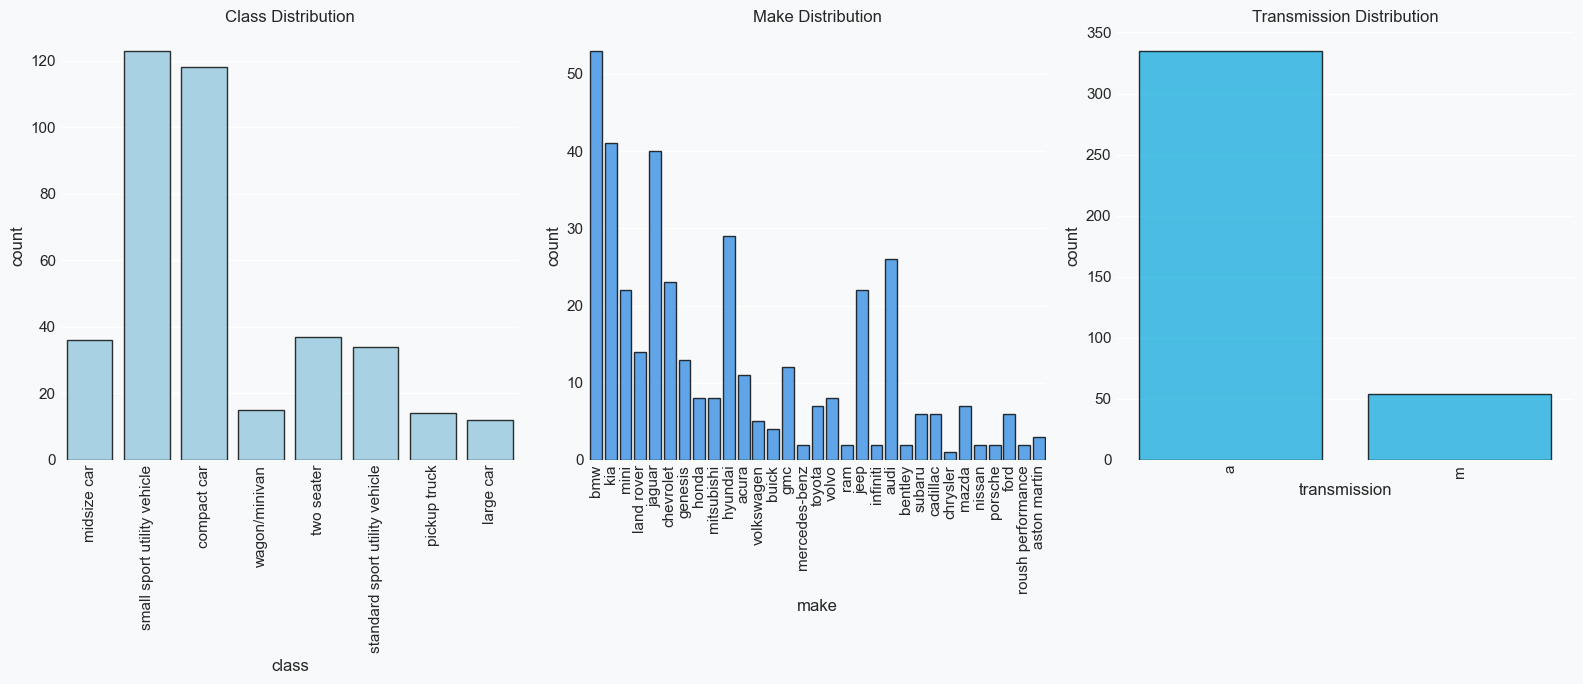

In [228]:
# List of categorical columns
categorical_columns = ['class', 'make','transmission']

# Set subplots and figure sie for plots
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

# Define colors
colors = ['skyblue', 'dodgerblue', 'deepskyblue']

glossy_style = {'alpha': 0.8, 'edgecolor': 'black'}  # Glossy effect

# Loop through the categorical columns
for i, col in enumerate(categorical_columns):
    # Plot the distribution for each categorical column
    sns.countplot(ax=axes[i], x=col, data=df, color=colors[i], **glossy_style)
    axes[i].set_title(f'{col.capitalize()} Distribution')
    axes[i].tick_params(axis='x', rotation=90)

# Adjust layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()

***Class Distribution***: There’s a clear imbalance in vehicle classes. compact vehicles and small sport utility vehicles dominate the dataset, while pickup-truck and wagons are less common. This suggests that certain car categories are underrepresented in the data.  

***Make Distribution***: Some manufacturers, such as BMW and Kia, have a notably strong presence in the dataset, likely due to their popularity. This higher representation could impact brand-based comparisons, as some brands may offer a more diverse range of vehicles than others  

***Transmission Distribution***: The majority of transmissions in the dataset are automatic, significantly outnumbering manual transmissions. This could be due to the ease of operation that automatic transmissions offer compared to manual ones.  


>    To gain deeper insights, even though some **vehicle classes**, **makes**, and **transmission types** are underrepresented, certain cars across different classes or with different transmissions,might still share similar **engine specifications**. As I progress with the analysis, I expect to uncover whether vehicles from different classes have comparable engine specs.  
   By examining **engine specifications**, I aim to determine if different vehicle classes with the **same engine specs** perform similarly or if factors like **weight** and **design** create significant differences. This will help in understanding whether class,transmission distinctions are purely structural or if they also impact **performance** despite having similar engines.

---


In [229]:
df

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
549,17,midsize car,19,8.0,4.4,awd,gas,24,bmw,alpina b8 gran coupe,a,2024
511,25,small sport utility vehicle,26,4.0,1.6,awd,gas,27,kia,seltos awd,a,2024
522,16,compact car,19,6.0,3.0,rwd,gas,23,bmw,m4 coupe,m,2024
521,23,compact car,27,4.0,2.0,awd,gas,33,bmw,430i xdrive convertible,a,2024
520,25,compact car,28,4.0,2.0,rwd,gas,34,bmw,430i convertible,a,2024
...,...,...,...,...,...,...,...,...,...,...,...,...
33,13,compact car,15,12.0,5.9,rwd,gas,19,aston martin,vanquish,a,2014
32,13,compact car,15,12.0,5.9,rwd,gas,19,aston martin,db9,a,2014
31,11,two seater,14,8.0,4.2,awd,gas,20,audi,r8,m,2014
30,11,two seater,14,8.0,4.2,awd,gas,20,audi,r8 spyder,m,2014


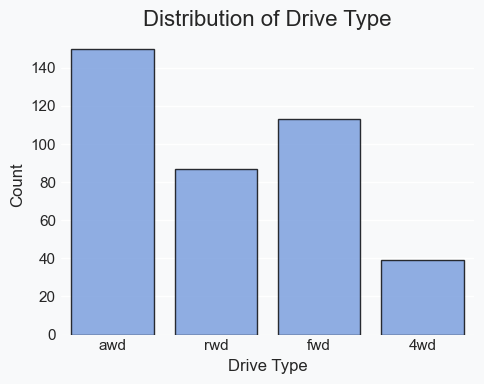

In [230]:
# Glossy style settings
glossy_style = {'alpha': 0.8, 'edgecolor': 'black'}  # Glossy effect

plt.figure(figsize=(5, 4)) 

# Plot the distribution )
sns.countplot(x=df['drive'], color='cornflowerblue', **glossy_style)
# Add title and labels
plt.title('Distribution of Drive Type', fontsize=16)
plt.xlabel('Drive Type')
plt.ylabel('Count')

# Adjust layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()


##### **Drive-Train**
A vehicle drivetrain refers to the components of a vehicle that transmit power from the engine to the wheels, enabling the vehicle to move.

The drivetrain is crucial in determining how a vehicle performs, particularly in terms of handling, traction, and off-road capability. Different drivetrain configurations are used for different purposes depending on the vehicle's design and intended use.
- ***AWD(All wheel drive)***: The high presence of this drivetrain in the plot could indicate that it is commonly used across a variety of vehicle classes, or it might be more prevalent in certain overrepresented classes,This drivetrain is known traction, stability, and control, particularly in adverse weather conditions

- ***FWD(Forward wheel drive)***: This drivetrain closely follows AWD, which is understandable given its widespread popularity in today’s vehicles, especially in compact cars and midsize cars. Its efficient design makes it a common choice for mass-market vehicles, contributing to its strong presence.

- ***RWD(Rear wheel drive)***: Typically found in high-performance or luxury cars, RWD offers better handling and balance. It ranks third in distribution within the dataset, and its notable presence indicates that it remains a popular choice among specific vehicle classes.

- ***4wd(4 wheel drive)***: Similar to AWD, which is designed for on-road driving to provide enhanced traction in varying weather conditions, 4WD is primarily suited for off-road use, offering better handling on rugged terrain. This distinction explains why 4WD appears less frequently in the dataset, it's a system typically found in vehicles designed for specific off-road capabilities, which may not be as common in everyday driving scenarios compared to the more road-oriented AWD systems.

---

In [30]:
# create df only including numerical feature
numeric_df = df.select_dtypes(include=['number'])

# extract numeric_df column names and store in a list
num_features = numeric_df.columns.to_list()

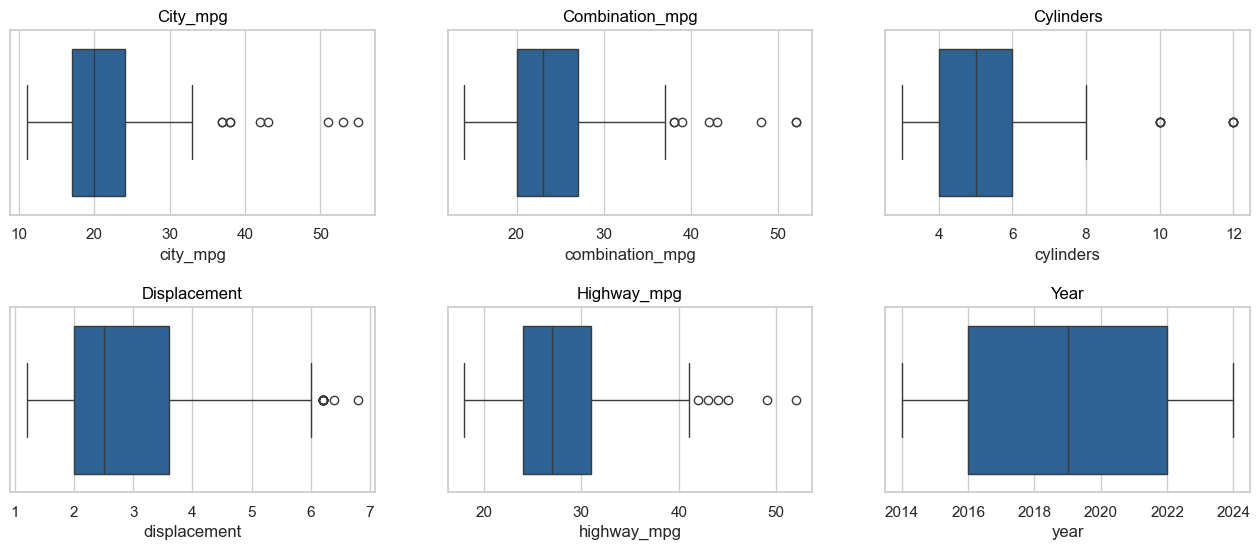

In [233]:
# Set subplots and figure size
figs, axes = plt.subplots(2, 3, figsize=(16,6))
axes = axes.flatten()  

# Set a glossy style 
sns.set(style="whitegrid", palette="muted")

# Create boxplots for each feature
for i, col in enumerate(num_features):
    sns.boxplot(x=df[col], ax=axes[i], color='#1D63A5',)
    axes[i].set_title(f"{col.capitalize()}", color="black") # set title for each feature

# set spacing
plt.subplots_adjust(hspace=0.5)
plt.show()

***MPG related box-plots***: 
- The boxplots for **City MPG, Highway MPG, and Combination MPG** give us a clear picture of how fuel efficiency varies across different driving conditions. **City MPG** tends to be lower, with most cars averaging around 20 MPG. The typical range is between 15 and 30 MPG, but there are a few standout vehicles that exceed 40 MPG, likely hybrids. **Highway MPG**, as expected, is higher because cars use fuel more efficiently at steady speeds. The median sits at 27 MPG, with most vehicles falling between 25 and 31 MPG. Again, there are some fuel-efficient cars that go beyond 40 MPG. **Combination MPG**, which balances both city and highway driving, falls somewhere in between, with a median of about 22 MPG and most cars landing between 20 and 27 MPG. The outliers across all three categories show that while most cars have a typical fuel efficiency, some newer(hybrids) achieve much better mileage.


***Cylinders & Displacement***
- The majority of cars (50%) in the dataset have between **4 and 6 cylinders**, which is typical. Around 25% of vehicles have fewer than **4 cylinders**, likely indicating **3-cylinder engines**. This aligns with the trend of newer cars adopting 3-cylinder engines for improved fuel efficiency and emissions compliance, making them less common in the dataset. The remaining 25% of cars have more than **6 cylinders**, typically ranging from **6 to 8**. These are likely larger vehicles, such as **SUVs** and **pickup trucks**. Outliers extend up to **12 cylinders**, which is not an error, as 12-cylinder engines do exist, primarily in high-performance **supercars**.

- The majority of cars (50%) have a **displacement** ranging from **2 to 3.5**, while a smaller portion (25%) have displacements between **4 and 6**. A few outliers, with displacements ranging from **6 to 7**, likely represent **high-performance vehicles**, such as **supercars**, that stand out due to their significantly larger engine sizes.


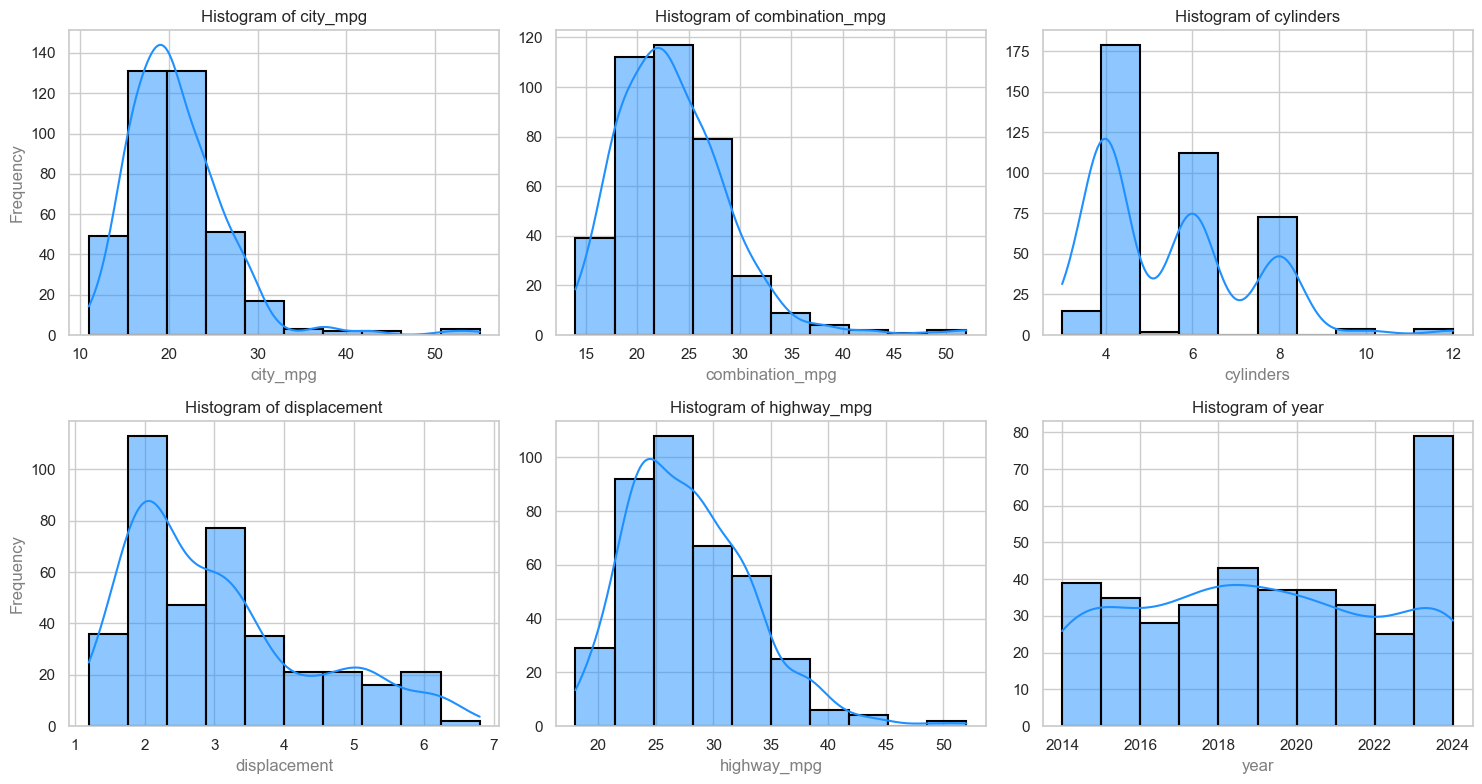

In [ ]:
# Get numeric columns
numeric_columns = numeric_df.columns

# Create subplots with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Flatten the axes array for easy iteration
axes = axes.flatten()  

# Set a glossy style
glossy_style = {'alpha': 0.8, 'edgecolor': 'black'} 

# Plot histograms for each numeric column 
for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=10, color='dodgerblue', edgecolor='black', linewidth=1.5)
    
    # Set titles, labels, and styles
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col, fontsize=12, color='gray')

    # set label to be on the far left for each row of plots
    if i == 0 or i == 3:
        axes[i].set_ylabel('Frequency', fontsize=12, color='gray')
    else:
        axes[i].set_ylabel('')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

***MPG related Histograms:**
- The **city_mpg** histogram shows a right-skewed distribution, with most vehicles having city mileage between 20-30 mpg
- The **highway_mpg** histogram follows a similar trend, peaking around 25-35 mpg, which indicates better fuel economy on highways. This aligns with the above box-plot analysis, as highways typically have fewer stops and starts.
- The **combination_mpg** histogram confirms the above box-plot analysis, with a peak between 20-30 mpg, reflecting a balance between city and highway mileage.

> The **right-skewed** nature of these distributions suggests that while most cars fall within a typical range, a few fuel-efficient models achieve significantly higher mpg, possibly due to being hybrid vehicles.

**Cylinders & Displacement Analysis:**
- Most vehicles have 4-cylinder engines, followed by 6-cylinder and then 8-cylinder vehicles.
- A small fraction of vehicles have 10 or 12 cylinders, likely high-performance.
- The displacement histogram is right-skewed, with a concentration around **2-3 liters**, which is typical for most passenger vehicles.

**Year Analysis**
- The year distribution appears fairly uniform but has a peak in recent years, indicating more data points from newer models.

---

#### ***Multivariate Analysis***

Multivariate analysis is a statistical approach used to examine the relationships between multiple variables simultaneously. In this **fuel economy** analysis, it helps identify how different factors, such as **engine size, vehicle class, drivetrain, and transmission** type interact to influence fuel **consumption**

To begin the analysis, the three most and least fuel-efficient vehicles in each category will be examined to identify key factors influencing fuel consumption. By examining this factors, valuable insights can be gained into what contributes to fuel efficiency and what leads to higher consumption.

__Identify Fuel-Efficient Vehicles__

In [ ]:
# create copy of original df
df_eda = df.copy()

# concatenate make and model to form new column make/model
df_eda['make/model'] = df_eda['make'].astype(str) + '-' + df_eda['model'].astype(str)

# create new feature to rank most fuel efficient in each class
df_eda['rank'] = df.groupby('class')['combination_mpg'].rank(method='first', ascending=False)

# filter to only keep top 3 most feul efficient in each class
top_in_class = (
    df_eda.sort_values(["class", "rank"], ascending=[True, True])  # Sort by class and rank (ascending for smallest rank)
    .drop_duplicates(subset=["class", "model"], keep="first")  # Remove duplicates by name within each class
    .groupby("class", group_keys=False)  # Group by vehicle class
    .head(3)  # Select the top 3 most fuel-efficient cars per class
)


# filter to only keep top 3 least feul efficient in each class
least_in_class = (
    df_eda.sort_values(["class", "rank"], ascending=[True, False])  # Sort by class and rank (descending)
    .drop_duplicates(subset=["class", "model"], keep="last")  # Remove duplicates, keeping the one with lowest MPG
    .groupby("class", group_keys=False)  # Group by vehicle class
    .head(3)  # Select the top 3 most fuel-efficient cars per class
)


In [234]:
# Extract unique car classes and define subplot grid
classes = top_in_class['class'].unique()
num_classes, cols = len(classes), 4
rows = -(-num_classes // cols)  # Equivalent to math.ceil(num_classes / cols)

# Shorten certain class names to avoid overlapping off titles in subplots
def clean_class_name(name):
    return name.replace("standard utility vehicle", "SUV").replace("sport utility vehicle", "SUV")

# Create subplots with dynamic titles
fig = make_subplots(
    rows=rows, cols=cols,
    subplot_titles=[f"Top 3 {clean_class_name(car_class)}s" for car_class in classes],
    horizontal_spacing=0.1
)

# Define color palettes
color_palettes = {
    "most": ['deepskyblue', 'dodgerblue', 'royalblue', 'steelblue', 'cornflowerblue', 'mediumblue', 'skyblue', 'slateblue'],
    "least": [    'salmon', 'tomato', 'coral', 'lightcoral', 'indianred', 'firebrick', 'orangered', 'darkred']
}
color_maps = {
    "most": {cls: color_palettes["most"][i % len(color_palettes["most"])] for i, cls in enumerate(classes)},
    "least": {cls: color_palettes["least"][i % len(color_palettes["least"])] for i, cls in enumerate(classes)}
}

# Custom hover template
hover_template = (
    "<b>%{x}</b><br>MPG: %{y}<br>Cylinders: %{customdata[0]}<br>Displacement: %{customdata[1]}L<extra></extra>"
)

# Function to add bar traces
def add_bar_trace(fig, data, car_class, label, color_map, row, col, visibility):
    fig.add_trace(
        go.Bar(
            x=data['make/model'], y=data['combination_mpg'],
            customdata=data[['cylinders', 'displacement']],
            hovertemplate=hover_template,
            marker=dict(color=color_map[car_class], line=dict(color='black', width=1.5)),
            name=f"{label}: {car_class}", showlegend=False, visible=visibility
        ),
        row=row, col=col
    )

# Track visibility states
visibility_map = {"most": [], "least": []}

# Loop through classes once and add both most & least efficient traces
for i, car_class in enumerate(classes):
    row, col = (i // cols) + 1, (i % cols) + 1

    # Add bar traces for most efficient cars
    add_bar_trace(fig, top_in_class[top_in_class['class'] == car_class].sort_values(by='rank'), 
                  car_class, "Most", color_maps["most"], row, col, True)
    visibility_map["most"].append(True)
    visibility_map["least"].append(False)

    # Add bar traces for least efficient cars
    add_bar_trace(fig, least_in_class[least_in_class['class'] == car_class].sort_values(by='rank'), 
                  car_class, "Least", color_maps["least"], row, col, False)
    visibility_map["most"].append(False)
    visibility_map["least"].append(True)

# Dropdown menu for toggling between most & least efficient cars
fig.update_layout(
    yaxis_title="Miles Per Gallon (MPG)",
    height=400 * rows, width=1200, title_text="Car Efficiency by Class",
    showlegend=False, plot_bgcolor='lightgrey', paper_bgcolor='#F5F5F5',
    title_y=0.95, hovermode='closest',
    updatemenus=[{
        "buttons": [
            {"args": [{"visible": visibility_map["most"]}, {"title": "Most Efficient Cars"}],
             "label": "Most Efficient", "method": "update"},
            {"args": [{"visible": visibility_map["least"]}, {"title": "Least Efficient Cars"}],
             "label": "Least Efficient", "method": "update"},
        ],
        "direction": "down", "x": 0.5, "y": 1.3, "xanchor": "right", "yanchor": "top"
    }]
)

# Update only the first subplot of each row with a y-axis label
for i in range(rows):  # Iterate through rows
    fig.update_layout({f'yaxis{(i * cols) + 1}_title': "Miles Per Gallon (MPG)"})
    
# Ensure only "most efficient" traces are visible initially
fig.update_traces(hoverlabel=dict(font=dict(color="white")))

fig.show()

# Save the plot as an HTML file
fig.write_html("top3_vehicles.html")

##### __Insights from the Interactive Fuel Efficiency Graph__

The interactive graph, which includes a **dropdown menu** to switch between the **most and least fuel-efficient cars** in each vehicle class, reveals key insights.  

**Most Fuel-Efficient Midsize Cars**  
- In the **midsize car** category, the **Honda Insight** ranks as the most fuel-efficient, achieving **52 mpg**. This is a significant difference compared to the **runner-up**, the **Hyundai Elantra**, which gets **34 mpg**. By taking advantage of the interactivity and hovering over the bars, it is revealed that both vehicles have **4-cylinder engines** with a **2L displacement**, making the efficiency difference even more striking, The large gap suggests that the Honda Insight could be a hybrid. 

**Least Fuel-Efficient Midsize Cars** 
- Switching to the **least fuel-efficient** midsize cars using the **dropdown menu**, the **BMW M8 Competition Gran Coupe** appears with just **17 mpg**. To make a **fair comparison**, the **Hyundai Elantra (34 mpg)** from the most efficient category is used as a reference, as there is no suspicion of it being a hybrid.  

**Key Differences: BMW M8 vs. Hyundai Elantra**

| Vehicle                        | Cylinders | Engine Displacement | Fuel Efficiency (mpg) |
|--------------------------------|-----------|----------------------|-----------------------|
| **BMW M8 Competition Gran Coupe** | 8         | 4.4L                 | 17                    |
| **Hyundai Elantra**            | 4         | 2L                   | 34                    |

- This comparison highlights a clear pattern—vehicles with **more cylinders and larger engine displacement** tend to have **higher fuel consumption**, while those with **fewer cylinders and smaller engines** are generally **more fuel-efficient**.  

Similar observations are seen across different vehicle classes, and this trend will be explored further in the analysis.


---

__Analyze Key Factors Influencing Fuel Efficiency__

In [35]:
# Compute correlation matrix
corr_df = numeric_df.corr()
annotations = np.round(corr_df.values, 2)

# Generate hover text with feature names and correlation values
hover_text = [[f"{corr_df.index[i]} & {corr_df.columns[j]}<br>Correlation: {annotations[i, j]}" 
               for j in range(len(corr_df.columns))] for i in range(len(corr_df.index))]

# Create heatmap
fig = go.Figure(data=go.Heatmap(z=corr_df.values, x=corr_df.columns, y=corr_df.index,
                                colorscale="RdBu", zmin=-1, zmax=1,
                                text=hover_text, hoverinfo="text", showscale=True))

# Add annotations(correlation values)
for i, row in enumerate(corr_df.index):
    for j, col in enumerate(corr_df.columns):
        fig.add_annotation(x=col, y=row, text=str(annotations[i, j]), showarrow=False,
                           font=dict(color="white", size=10))

# Improve layout aesthetics & reduce plot size
fig.update_layout(
    title="Correlation Heatmap",
    margin=dict(l=50, r=50, t=50, b=50),  # Tight margins

)


fig.show()


The heatmap analysis confirms that the **mpg** features are significantly influenced by **cylinders** and **displacement**, showing a strong **negative correlation**. This indicates that vehicles with a higher number of **cylinders** and larger **displacement** tend to have lower fuel efficiency (**mpg**). Additionally, the analysis suggests that the **year** feature has a low correlation with **mpg**, implying a **non-linear relationship** between **mpg** and the vehicle's manufacturing **year**.


---

In [36]:
# Calculate the average for each column
fuel_consumption = {
    'City MPG': df['city_mpg'].mean(),
    'Combination MPG': df['combination_mpg'].mean(),
    'Highway MPG': df['highway_mpg'].mean()
}

# Create subplots (1 row, 3 columns)
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('Average Fuel Consumption by MPG Category', 'MPG vs Cylinders', 'Displacement vs MPG'),
    specs=[[{"type": "bar"}, {"type": "scatter"}, {"type": "scatter"}]]
)

# First subplot: Bar plot of average MPG by category
fig.add_trace(go.Bar(
    x=list(fuel_consumption.keys()), 
    y=list(fuel_consumption.values()), 
    marker=dict(color=['#636EFA', '#00CC96', '#EF553B'], line=dict(color='#2D3A4A', width=1)),
    opacity=0.85, name='MPG Types'
), row=1, col=1)

# Second subplot: Line plot of MPG vs cylinders
mpg_by_cylinders = df.groupby('cylinders')[['combination_mpg', 'city_mpg', 'highway_mpg']].mean().reset_index()
for col, label, color in zip(['combination_mpg', 'city_mpg', 'highway_mpg'], 
                             ['Combination MPG', 'City MPG', 'Highway MPG'], 
                             ['#636EFA', '#00CC96', '#EF553B']):
    fig.add_trace(go.Scatter(
        x=mpg_by_cylinders['cylinders'], y=mpg_by_cylinders[col], 
        mode='lines+markers', name=label, line=dict(width=2.5),
        marker=dict(size=8, color=color, line=dict(width=1, color='#2D3A4A'))
    ), row=1, col=2)

# Third subplot: Scatter plot of displacement vs MPG
disp_group = df.groupby('displacement')[['combination_mpg', 'city_mpg', 'highway_mpg']].mean().reset_index()
for col, label, color in zip(['combination_mpg', 'city_mpg', 'highway_mpg'], 
                             ['Combination MPG', 'City MPG', 'Highway MPG'], 
                             ['#636EFA', '#00CC96', '#EF553B']):
    fig.add_trace(go.Scatter(
        x=disp_group['displacement'], y=disp_group[col], mode='markers', name=label, 
        marker=dict(size=8, color=color, opacity=0.8, line=dict(width=1, color='#2D3A4A'))
    ), row=1, col=3)

# Update layout with axis labels, legend, and styling
fig.update_layout(
    height=500, width=1400, title_text="<b>Fuel Consumption and MPG Analysis</b>", 
    title_font=dict(size=20, family='Arial', color='#2D3A4A'), showlegend=True, 
    plot_bgcolor='rgba(240,240,240,0.8)', paper_bgcolor='white', 
    legend=dict(orientation="v", yanchor="top", y=0.99, xanchor="left", x=1.02), 
    margin=dict(l=50, r=150, t=80, b=50)
)

# Axis updates
for axis, title in zip(['x', 'y'], ['MPG Category', 'Average MPG', 'Number of Cylinders', 'MPG', 'Engine Displacement', 'MPG']):
    fig.update_xaxes(title_text=title, showgrid=True, gridwidth=1, gridcolor='rgba(200,200,200,0.5)', linecolor='#2D3A4A', title_font=dict(size=12))
    fig.update_yaxes(title_text=title, showgrid=True, gridwidth=1, gridcolor='rgba(200,200,200,0.5)', linecolor='#2D3A4A', title_font=dict(size=12))

# Style subplot titles
for annotation in fig['layout']['annotations']:
    annotation['font'] = dict(size=14, family='Arial', color='#2D3A4A')

fig.show()


**Average Fuel Consumption by MPG Category (Bar Chart)**
- Highway MPG is the highest, followed by Combination MPG, and then City MPG.
- This is due to the consistent speed and fewer stops associated with highway driving, which makes it more fuel-efficient than city driving, where frequent starts and stops are common.

**2. MPG vs Cylinders (Line Chart)**
- As the number of cylinders increases, the average MPG decreases.
- This indicates that vehicles with more cylinders tend to be less fuel-efficient.

**3. Displacement vs MPG (Scatter Plot)**
- There is a negative correlation between engine displacement and MPG, which was also revealed in the previous heatmap.
- Larger engine displacements generally result in lower fuel efficiency.
- The trend is consistent across City MPG, Highway MPG, and Combination MPG.


>- **Highway driving** is more fuel-efficient than city driving.
>- Vehicles with **more cylinders** consume more fuel.
>- Larger **engine displacement** reduces fuel efficiency.



---

The next step is to compare vehicles with the same engine specifications across different classes to analyze the impact of weight on fuel efficiency. Since the dataset is imbalanced, vehicle classes with similar entry counts will be selected to ensure a fair comparison.

In [37]:
# check class count to see which classes cant be fairly compared
df_eda.groupby('class')['class'].count()

class
compact car                       118
large car                          12
midsize car                        36
pickup truck                       14
small sport utility vehicle       123
standard sport utility vehicle     34
two seater                         37
wagon/minivan                      15
Name: class, dtype: int64

The analysis will focus on compact cars and small sport utility vehicles, selecting only those with 4-cylinder engines and a 2L displacement. This will help determine whether there are differences in MPG between these two classes when engine specifications are consistent, providing insights into the impact of vehicle weight.

In [38]:
# Filter out other classes and keep suv an compact car
filtered_df = df[(df['class'] == 'compact car') | (df['class'] == 'small sport utility vehicle')]
filtered_df.head()

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
511,25,small sport utility vehicle,26,4.0,1.6,awd,gas,27,kia,seltos awd,a,2024
522,16,compact car,19,6.0,3.0,rwd,gas,23,bmw,m4 coupe,m,2024
521,23,compact car,27,4.0,2.0,awd,gas,33,bmw,430i xdrive convertible,a,2024
520,25,compact car,28,4.0,2.0,rwd,gas,34,bmw,430i convertible,a,2024
519,23,compact car,27,4.0,2.0,awd,gas,33,bmw,430i xdrive coupe,a,2024


In [39]:
# filter vehicles from the two different classes with similiar spec
similiar_spec = filtered_df[(filtered_df['cylinders'] == 4) & (filtered_df['displacement'] == 2 )]
similiar_spec.head()

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
521,23,compact car,27,4.0,2.0,awd,gas,33,bmw,430i xdrive convertible,a,2024
520,25,compact car,28,4.0,2.0,rwd,gas,34,bmw,430i convertible,a,2024
519,23,compact car,27,4.0,2.0,awd,gas,33,bmw,430i xdrive coupe,a,2024
518,25,compact car,28,4.0,2.0,rwd,gas,34,bmw,430i coupe,a,2024
517,25,compact car,28,4.0,2.0,fwd,gas,33,mini,john cooper works convertible,a,2024


In [40]:
# see count for fair comparison
similiar_spec.groupby('class')['class'].count()

class
compact car                    42
small sport utility vehicle    40
Name: class, dtype: int64

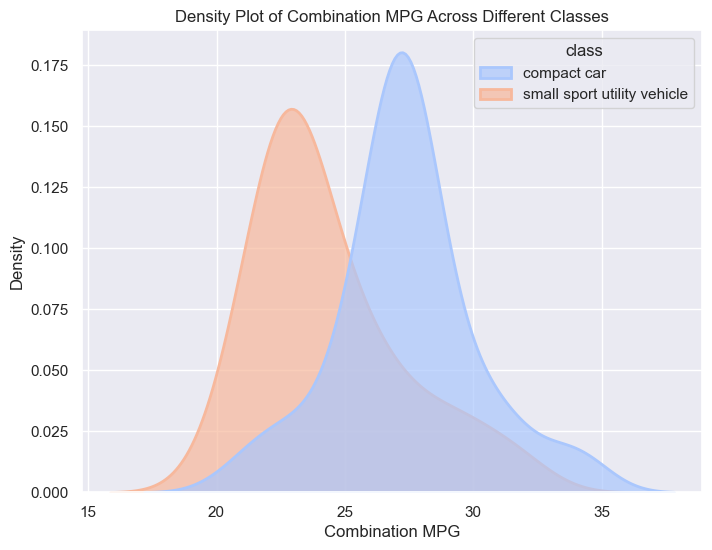

In [41]:
# Set seaborn style
sns.set(style="darkgrid")

# Create figure and axis
plt.figure(figsize=(8, 6))

# Density plot 
sns.kdeplot(
    data=similiar_spec, 
    x='combination_mpg', 
    hue='class', 
    fill=True, 
    common_norm=False, 
    palette="coolwarm",  
    alpha=0.7,  
    linewidth=2  
)

# Add labes
plt.title('Density Plot of Combination MPG Across Different Classes')
plt.xlabel('Combination MPG')
plt.ylabel('Density')

# Show the plot
plt.show()


**Compact Cars Have Higher Fuel Efficiency:**
   - The peak of the **blue curve (compact cars)** is around **27-28 MPG**, meaning most compact cars achieve better fuel economy.
   - Their density is more spread out, reaching around **35 MPG**, indicating some compact cars achieve even higher fuel efficiency.

**Small SUVs Have Lower Fuel Efficiency:**
   - The **orange curve (small SUVs)** peaks around **22-23 MPG**, which is significantly lower than compact cars.
   - The distribution is more concentrated, meaning most small SUVs fall within a tighter MPG range.

**Overlap Between The Two Classes:**
   - The two distributions overlap between **22 and 28 MPG**, meaning some SUVs achieve similar fuel efficiency to compact cars.
   - However, **compact cars dominate the higher MPG range**, while SUVs are more concentrated in the lower range.

**Weight Likely Affects Fuel Efficiency:**
   - Since the engine specifications are similar, the difference in MPG suggests that **vehicle weight plays a significant role in fuel efficiency**.
   - SUVs, being heavier, require more energy to move, which likely explains their lower MPG.

To gain a broader perspective, a bar graph of all vehicle classes will be plotted, even though the dataset is imbalanced. While this imbalance may introduce some bias, the goal is to observe general trends across different vehicle categories and explore how fuel efficiency varies on a larger scale.

In [42]:
# Group by vehicle class and calculate mean MPG values
class_df = df.groupby('class')[['combination_mpg', 'city_mpg', 'highway_mpg']].mean().reset_index()


# Melt the DataFrame to long format for Plotly
df_long = class_df.melt(id_vars=['class'], value_vars=['city_mpg', 'highway_mpg', 'combination_mpg'],
                         var_name='MPG_Type', value_name='MPG')

# Create an interactive bar plot
fig = px.bar(df_long, x='class', y='MPG', color='MPG_Type', 
             title='Fuel Consumption by Vehicle Class',
             labels={'MPG': 'Miles Per Gallon (MPG)', 'class': 'Vehicle Class'},
             barmode='group')

# Customize layout
fig.update_layout(height=600, width=1000, xaxis_tickangle=-45, legend_title_text='MPG Type')

# Show the interactive plot
fig.show()


**Higher MPG on Highways:**  
   - Vehicles generally achieve higher miles per gallon (MPG) on highways compared to city driving. While previous analyses confirmed this trend across all cars, this deeper analysis examines whether the same pattern holds true within individual vehicle classes.

 **Compact and Midsize Cars Perform Better:**  
   - On average, compact cars and midsize cars tend to have better fuel consumption across all types of MPG (city, highway, and combined). This is likely due to their smaller size, lighter weight, and more efficient design.

**SUVs and Pickup Trucks Have Lower MPG:**  
   - Standard SUVs and pickup trucks, due to their larger size and heavier weight, typically achieve lower MPG across all categories. Their larger engines and increased drag contribute to higher fuel consumption, making them less efficient compared to smaller vehicles.

**Two-Seaters Show Poor MPG Despite Smaller Size:**  
   - Although two-seater cars are small, they tend to have poorer fuel efficiency. This could be attributed to their design as sporty or performance-oriented vehicles, which often prioritize power and speed over fuel economy. As a result, these vehicles consume more fuel despite their smaller size.

---

In [43]:
# Create violin plot
fig = px.violin(df, 
                y='drive', 
                x='combination_mpg', 
                color='drive', 
                box=True, 
                points="all", 
                title="Average MPG by Drive Train",
                orientation='h')

# Show the plot
fig.show()

* **FWD (Front-Wheel Drive):** The distribution for FWD is generally shifted towards the higher end of the MPG scale, suggesting that vehicles with front-wheel drive tend to have better fuel efficiency on average.
* **RWD (Rear-Wheel Drive) and 4WD (Four-Wheel Drive):** The distributions for RWD and 4WD are typically located towards the lower end of the MPG scale, indicating lower average fuel efficiency compared to FWD.
* **AWD (All-Wheel Drive):** The AWD distribution shows a broader range of MPG values, with its central tendency falling between FWD and RWD/4WD.
* **TWD (Two-Wheel Drive):** This drive type exhibits a narrower distribution centered at a slightly lower MPG than FWD.

**Implications**

This analysis suggests a correlation between drivetrain type and fuel efficiency. Front-wheel drive vehicles in this dataset generally exhibit the highest combined MPG, while rear-wheel and four-wheel drive vehicles tend to have lower fuel efficiency. This trend makes sense, as FWD is typically found in smaller cars, as shown in the plot below, whereas other drivetrain types are more common in larger, more spacious vehicles.

In [44]:
# Group and count occurrences of each drive type per class
count_df = df.groupby(['class', 'drive']).size().reset_index(name='count')

# Create stacked bar plot
fig = px.bar(count_df, 
             x='class', 
             y='count', 
             color='drive', 
             barmode='relative',  # 'relative' makes it a stacked bar chart
             title="Drive Types by Vehicle Class")

# Show the plot
fig.show()


Next, we will examine the relationship between transmission type and fuel consumption efficiency

In [45]:
# Calculate the average MPG values grouped by transmission type
fuel_by_transmission = df.groupby('transmission')[['combination_mpg', 'city_mpg', 'highway_mpg']].mean().reset_index()

# Reshape the dataframe for plotting
df_melted = fuel_by_transmission.melt(id_vars='transmission', 
                                      value_vars=['combination_mpg', 'city_mpg', 'highway_mpg'],
                                      var_name='MPG Type', value_name='MPG')

# Define color scheme
blue_colors = ['#4a90e2', '#3572a5', '#204a87']

# Create an interactive bar chart with Plotly
fig = px.bar(df_melted, 
             x='transmission', 
             y='MPG', 
             color='MPG Type', 
             barmode='group',
             title='MPG Comparison by Transmission Type')

# Customize layout
fig.update_layout(
    xaxis_title="Transmission Type",
    yaxis_title="Miles Per Gallon (MPG)",
    xaxis_tickangle=20,
    template="plotly_white",
    legend_title_text="MPG Type"
)

# Show the interactive plot
fig.show()


Interestingly, the transmission type doesn't make a big difference for fuel economy overall. The one exception is highway driving, where automatics edge out manuals by a small but consistent margin.

---

##### **Explore Yearly Trends**

In [46]:
# Calculate yearly trends by averaging MPG values for each year
yearly_trends = df.groupby('year')[['city_mpg', 'highway_mpg', 'combination_mpg']].mean()

# Create an interactive Plotly figure
fig = go.Figure()

# Add traces for each MPG type
for column in yearly_trends.columns:
    fig.add_trace(go.Scatter(
        x=yearly_trends.index,
        y=yearly_trends[column],
        mode='lines+markers',
        name=column
    ))

# Customize layout
fig.update_layout(
    title='Fuel Efficiency over 10 years',
    xaxis_title='Year',
    yaxis_title='MPG (Miles Per Gallon)',
    template='plotly_white',
    legend_title='MPG Type',
    hovermode='x unified'
)

# Show figure
fig.show()


- The line graph(Fuel efficiency over 10 years) shows a steady upward trend in fuel efficiency (MPG) over the 10-year period, with a noticeable peak in 2020–2021 followed by a sharp dip between 2021–2023.

- An explanation for the peak during 2020–2021 could be advancements in hybrid vehicle technology or changes in driving patterns due to the COVID-19 pandemic. With fewer people on the roads, those who did drive may have experienced less traffic congestion, leading to more efficient driving with fewer stop-and-go conditions. The subsequent dip between 2021–2023 might be attributed to the return of normal traffic patterns, increased driving activity.

---

## **Modeling**
<a id="six"></a>
<a href=#cont>Back to Table of Contents</a>



### **Preprocessing & Feature Engineering**

Preprocessing and feature engineering are crucial steps in preparing data for analysis. they involve organizing and transforming raw data into a structured format that can be easily interpreted by algorithms. A key part of this process is converting categorical data into numerical form, allowing models to understand and work with the data more effectively. This could include turning categories into labels or using techniques like one-hot encoding to represent different categories as binary columns and also adjustin the scale of numerical data.

In [47]:
# make a copy of original dataframe
model_df = df.copy()

Features that are not needed will be dropped based on our analysis, as they do not have a significant impact on the model’s performance. city_mpg and highway_mpg are removed because they could introduce leakage. Since our target variable will be combination_mpg, which is derived from the city_mpg and highway_mpg values, retaining these features could lead to data leakage, as they are closely related to the target.

In [48]:
# Drop features()
model_df.drop(columns=['city_mpg', 'highway_mpg','model','transmission','make','fuel_type'],inplace=True)

In [49]:
# Overview of model_df
model_df.head()

,class,combination_mpg,cylinders,displacement,drive,year
549,midsize car,19,8.0,4.4,awd,2024
511,small sport utility vehicle,26,4.0,1.6,awd,2024
522,compact car,19,6.0,3.0,rwd,2024
521,compact car,27,4.0,2.0,awd,2024
520,compact car,28,4.0,2.0,rwd,2024


Transform categorical data to numerical data

In [50]:
# Perform one-hot encoding on categorical columns
df_encoded = pd.get_dummies(model_df, columns=['class', 'drive'], dtype=int, drop_first=True)


In [51]:
# overview of encoded dataframe
df_encoded.head()

,combination_mpg,cylinders,displacement,year,class_large car,class_midsize car,class_pickup truck,class_small sport utility vehicle,class_standard sport utility vehicle,class_two seater,class_wagon/minivan,drive_awd,drive_fwd,drive_rwd
549,19,8.0,4.4,2024,0,1,0,0,0,0,0,1,0,0
511,26,4.0,1.6,2024,0,0,0,1,0,0,0,1,0,0
522,19,6.0,3.0,2024,0,0,0,0,0,0,0,0,0,1
521,27,4.0,2.0,2024,0,0,0,0,0,0,0,1,0,0
520,28,4.0,2.0,2024,0,0,0,0,0,0,0,0,0,1


Define the features and the target variable,also split the data in train,test and validation set

In [52]:
# Define Features and target variable
X = df_encoded.drop('combination_mpg', axis=1)
y = df_encoded['combination_mpg']

# Split the data into train (75%) and test (25%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Scale features to ensure each feature contributes equally to the model

In [ ]:
# define scaler
scaler = StandardScaler()

# scale numeric feature
X_train[['cylinders', 'displacement', 'year']] = scaler.fit_transform(X_train[['cylinders', 'displacement', 'year']])
X_test[['cylinders', 'displacement', 'year']] = scaler.transform(X_test[['cylinders', 'displacement', 'year']])


In [54]:
# Check the sizes of the splits
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Training set size: 291
Test set size: 98


---


### __Model Development__

##### **Linear Regression (Base Model)**

A multiple linear regression model is a type of statistical technique used to understand the relationship between one dependent variable and two or more independent variables. Essentially, it helps to predict or explain the value of a target (dependent) variable based on the values of several other factors (independent variables).

For example, if you wanted to predict someone's weight (the dependent variable) based on their height, age, and diet (independent variables), you could use a multiple linear regression model. It works by finding the best-fit line (or hyperplane in higher dimensions) that minimizes the difference between the predicted and actual values.

In simpler terms, it’s like drawing a line or a plane in a multi-dimensional space to make the best guess about how one thing depends on others. The model also provides a way to see how much each independent variable contributes to the prediction.


In [55]:
# Initialize the Linear Regression model
lr_model = LinearRegression()


In [ ]:
# Define the metrics
scoring_metrics = {
    'mae': make_scorer(mean_absolute_error),  # MAE
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))  # RMSE
}

With small datasets, models are at a higher risk of overfitting, meaning they might perform well on the training data but poorly on unseen data. **Cross-validation** helps by evaluating the model on different subsets, giving a more reliable estimate of performance and reducing the chances of overfitting to a specific data split.

In [190]:
# Perform 5-fold cross-validation with both MAE and RMSE
cv_results_lr = cross_validate(lr_model, X_train, y_train, scoring=scoring_metrics, cv=5)

In [58]:
# Fit the model on the entire training set
lr_model.fit(X_train, y_train)

# Evaluate the model on the hold-out test set
y_pred_lr = lr_model.predict(X_test)

In [ ]:
# Get average metrics for cv(training data) to compare with test set for generalization
cv_mae_lr = np.mean(cv_results_lr['test_mae'])
cv_rmse_lr = np.mean(cv_results_lr['test_rmse'])

# Calculate MAE and RMSE on the test set
lr_test_mae = mean_absolute_error(y_test, y_pred_lr)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_test_r2 = r2_score(y_test, y_pred_lr)

# Print metric scores for train and test set
print("Average MAE from CV:", cv_mae_lr)
print("Final MAE on the test set:", lr_test_mae)

print("\nAverage RMSE from CV:", cv_rmse_lr)
print("Final RMSE on the test set:", lr_test_rmse)

print("\nR² on the test set:", lr_test_r2)

Average MAE from CV: 2.2802264130075343
Final MAE on the test set: 1.8201917632417046

Average RMSE from CV: 3.4177771701142823
Final RMSE on the test set: 2.7981472192407604

R² on the test set: 0.7167053607777772



- The **CV MAE** (2.040) is slightly higher than the **Test MAE** (1.820), suggesting it generalizes well to unseen data. The CV MAE acts as a robust estimate of expected performance
- Similarly, the **CV RMSE** (3.238) is higher than the **test RMSE** (2.798), indicating that the model is performing better on the test set. The difference is not large, which suggests the model is generalizing well, This could imply that the test set has fewer outliers
- The **test R²** of 0.717 is a good value, indicating that the model explains 71% of the variance in the test data. This shows that the model is capturing the underlying patterns in the data well.

The evaluation metrics indicate that the model's predictions closely align with the actual values, with an average deviation of less than **3 MPG**, demonstrating strong predictive accuracy.

The small differences between the CV and test set performance indicate that the model is generalizing well, with no signs of severe overfitting **(test metrics ≈ or better than CV metrics)**.. The solid **R²** value on the test set also supports the model's ability to make accurate predictions on unseen data. This is a good sign of a well-balanced model with reasonable complexity, neither underfitting nor overfitting.


 **Model Optimization**

The linear regression model has fewer parameters to optimize as compared to other models like decision trees, as it is a simple model. Therefore, cross-validation was the best optimization technique applied to ensure the model's performance was robust and generalizable.

**Actual vs Predicted values**

In [187]:
# Residuals
residuals = y_test - y_pred_lr

# Create subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=["Actual vs Predicted", "Residuals vs Predicted"])

# Actual vs Predicted
fig.add_scatter(x=y_test, y=y_pred_lr, mode='markers', marker=dict(color='blue', opacity=0.6), name='Predicted', row=1, col=1)
fig.add_scatter(x=[min(y_test), max(y_test)], y=[min(y_test), max(y_test)],
                mode='lines', line=dict(color='red', dash='dash'), name='Perfect Line', row=1, col=1)

# Residuals
fig.add_scatter(x=y_pred_lr, y=residuals, mode='markers', marker=dict(color='purple', opacity=0.6), name='Residuals', row=1, col=2)
fig.add_scatter(x=[min(y_pred_lr), max(y_pred_lr)], y=[0, 0],
                mode='lines', line=dict(color='red', dash='dash'), name='Zero Error', row=1, col=2)

# Layout
fig.update_layout(title='Actual vs Predicted and Residuals Plot', height=500, width=1000,
                  showlegend=False, xaxis_title="Actual Values", yaxis_title="Predicted Values",
                  xaxis2_title="Predicted Values", yaxis2_title="Residuals")

fig.show()

**Actual vs Predicted Plot**
- The predictions are not far over the regression line which is a good sign but the model seems to slightly overpredict at lower values and underpredict at higher values

**Residuals Plot**
- The residuals appear to be mostly scattered around the horizontal line at zero.
- However, there might be a slight indication of non-constant variance (heteroscedasticity). The spread of the residuals seems slightly wider at higher predicted values compared to lower predicted values
- There are a few outliers (points further away from the zero line), which could be influential data points or indicate areas where the model underperforms.

---

##### **Random Forest**

Random Forest is like a team of decision-makers. Imagine you need to make a tough decision, so you ask a group of experts for their opinions. Each expert (or "tree" in the forest) looks at the problem from a slightly different angle. Once they've all made their decisions, you take the most popular or most common answer. This way, you get a more accurate, reliable decision than if you just asked one person.

In the case of Random Forest, each "tree" is a simple model that makes a prediction, and the overall prediction is based on the combined results of all the trees. It’s great for handling complex data and avoids overfitting, making it a solid choice for many tasks like classification or regression.

In [135]:
# Initialize the RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42)


In [136]:

# Define the metrics to be used in the cross-validation
scoring_metrics = {
    'mae': make_scorer(mean_absolute_error),  # MAE
    'rmse': make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)))  # RMSE
}

# Cross-validation on the training data
cv_results_rf = cross_validate(rf_model, X_train, y_train, scoring=scoring_metrics, cv=5)


In [137]:
# Fit the model on the entire training set
rf_model.fit(X_train, y_train)

# Evaluate the model on the hold-out test set
y_pred_rf = rf_model.predict(X_test)


In [ ]:
# Calculate MAE and RMSE on the test set
rf_test_mae = mean_absolute_error(y_test, y_pred_rf)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_test_r2 = r2_score(y_test, y_pred_rf)

# Get average metrics for cv(training data) to compare with test set for generalization
cv_mae_rf = np.mean(cv_results_rf['test_mae'])
cv_rmse_rf = np.mean(cv_results_rf['test_rmse'])

# Print metric scores for train and test set
print("Average MAE from CV:", cv_mae_rf)
print("Final MAE on the test set:", rf_test_mae)

print("\nAverage RMSE from CV:", cv_rmse_rf)
print("Final RMSE on the test set:", rf_test_rmse)

print("\nR² on the test set:", rf_test_r2)


Average MAE from CV: 2.0202496108249175
Final MAE on the test set: 1.765169200272516

Average RMSE from CV: 3.1504171562597088
Final RMSE on the test set: 3.019969618702528

R² on the test set: 0.6700087809515021


- **MAE (Mean Absolute Error)** dropped from **2.020** (CV) to **1.765** (test set), indicating better accuracy in predicting individual values on unseen data.

- **RMSE (Root Mean Squared Error)** decreased from **3.150** (CV) to **3.02** (test set), showing less deviation from the true values on the test set.

- **R²** of 0.67 on the test set suggests that the model explains **67%** of the variance, which is moderate predictive power.

The test MAE demonstrates minimal deviation from the true values, and the RMSE yields a value of 3 mpg, which is acceptable but can still be improved.

**Hyperparameter Tuning(RandomForest)**

To elevate the performance of the Random Forest model, hyperparameter tuning will be implemented. To begin, a parameter grid will be defined, and grid search will be applied, systematically exploring the optimal hyperparameters to maximize accuracy and generalization.

In [142]:
# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [ ]:
# Apply GridSearchCV with cross-validation
grid_searchrf = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring=scoring_metrics, refit='mae', cv=5)

# Fit GridSearchCV to find the best parameters
grid_searchrf.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'bootstrap': [True, False],
                         'max_depth': [None, 10, 20, 30, 50],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300, 500]},
             refit='mae',
             scoring={'mae': make_scorer(mean_absolute_error),
                      'rmse': make_scorer(<lambda>)})

In [ ]:

# Best hyperparameters from GridSearchCV
best_params = grid_searchrf.best_params_

# Print best hyperparameters
print("Best hyperparameters from GridSearchCV:", best_params)


Best hyperparameters from GridSearchCV: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [ ]:
cv_results_rftuned = pd.DataFrame(grid_searchrf.cv_results_)

# Best score index
best_index = grid_searchrf.best_index_

# Get average metrics to compare with test set for generalization
avgtunedrf_cv_mae = cv_results_rftuned.loc[best_index, 'mean_test_mae']
avgtunedrf_cv_rmse = cv_results_rftuned.loc[best_index, 'mean_test_rmse']

In [ ]:
# Get the best model from GridSearchCV
best_rf_model = grid_searchrf.best_estimator_

# Fit the best model on the entire training set
best_rf_model.fit(X_train, y_train)

# Evaluate the model on the hold-out test set_
y_pred_bestrf = best_rf_model.predict(X_test)


# Calculate MAE and RMSE on the test set
bestrf_test_mae = mean_absolute_error(y_test, y_pred_bestrf)
bestrf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_bestrf))
bestrf_test_r2 = r2_score(y_test, y_pred_bestrf)


# Print metrics score for CV(Training data) and Test set
print("Average MAE from CV:", avgtunedrf_cv_mae)
print("Final MAE on the test set:", bestrf_test_mae)

print("\nAverage RMSE from CV:", avgtunedrf_cv_rmse)
print("Final RMSE on the test set:", bestrf_test_rmse)

print("\nR² on the test set:", bestrf_test_r2)

Average MAE from CV: 1.995136078970282
Final MAE on the test set: 1.750383864564874

Average RMSE from CV: 3.0656722467438646
Final RMSE on the test set: 2.540308976885727

R² on the test set: 0.7665089051473035


After hyperparameter tuning, the model showed slight improvements in performance compared to the untuned model:

- **Test MAE**: The test MAE slightly decreased from **1.765** (untuned) to **1.1.750** (tuned),although its an improve but the difference is insignificant.
- **Test RMSE**: The test RMSE decreased from **3.02** (untuned) to **2.540** (tuned),indicating a notable improvement.
- **R²**: The R² value increase from **67%** to **76%** which is a great improvement

The random forest model seemed to have shown improvements in metrics after tuning.

The evaluation metrics indicate that the model's predictions closely align with the actual values, with an average deviation of less than **3 MPG**, demonstrating strong predictive accuracy.

In [ ]:
# Actual vs Predicted Plot 
fig = make_subplots(rows=1, cols=2, subplot_titles=('Actual vs Predicted', 'Residuals Plot'))

# Actual vs Predicted scatter plot
fig.add_trace(go.Scatter(x=y_test, y=y_pred_bestrf, mode='markers', name='Actual vs Predicted', 
                         marker=dict(color='blue', opacity=0.6)), row=1, col=1)

# Line of perfect prediction & Residuals scatter plot
fig.add_trace(go.Scatter(x=[min(y_test), max(y_test)], y=[min(y_test), max(y_test)], mode='lines', 
                         name='Perfect Prediction', line=dict(color='red', dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=y_pred_bestrf, y=y_test - y_pred_bestrf, mode='markers', name='Residuals', 
                         marker=dict(color='green', opacity=0.6)), row=1, col=2)

# Zero residual line
fig.add_trace(go.Scatter(x=[min(y_pred_bestrf), max(y_pred_bestrf)], y=[0, 0], mode='lines', 
                         name='Zero Residual Line', line=dict(color='black', dash='dash')), row=1, col=2)

# Update layout
fig.update_layout(title='Actual vs Predicted and Residuals Plot', height=500, width=1000,
                  showlegend=False, xaxis_title="Actual Values", yaxis_title="Predicted Values",
                  xaxis2_title="Predicted Values", yaxis2_title="Residuals")

fig.show()

**Actual vs Predicted Plot:**
- The points are clustered around the line (which represents the ideal line where actual = predicted), indicating that the model predictions are generally close to the actual values.
- Some dispersion is visible, especially at higher actual values (above 35), where predictions tend to underestimate

**Residuals Plot**
- Residuals (errors) are mostly scattered around the zero line, with no clear pattern, which is a good sign, it implies the errors are randomly distributed.
- A few outliers are present, especially on the upper side, indicating some larger errors in predictions for certain instances.
- No funnel shape or systematic curvature is observed, so there’s no immediate sign of heteroscedasticity or non-linearity.


---

##### **K-Nearest Neighbors (KNN) Regressor**

K-Nearest Neighbors (KNN) Regressor is a non-parametric machine learning algorithm used for regression tasks. It works by finding the k nearest data points to a given input and predicting the output as the average (or weighted average) of the target values of those nearest neighbors.

The key idea is that similar data points tend to have similar output values. The value of k (the number of neighbors) is a crucial hyperparameter. A small value of k may lead to a model that is sensitive to noise, while a large k can smooth out the predictions but may miss subtle patterns.

In [98]:
# Initialize the KNeighborsRegressor model
knn_model = KNeighborsRegressor()


In [99]:

# Cross-validation on the training data
cv_results = cross_validate(knn_model, X_train, y_train, scoring=scoring_metrics, cv=5)


In [100]:
# Fit the model on the entire training set
knn_model.fit(X_train, y_train)


KNeighborsRegressor()

In [ ]:
# Evaluate the model on the hold-out test set
y_pred_knn = knn_model.predict(X_test)

In [ ]:
# Calculate MAE and RMSE on the test set
knn_test_mae = mean_absolute_error(y_test, y_pred_knn)
knn_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
knn_test_r2 = r2_score(y_test, y_pred_knn)

# Get average metrics to compare with test set for generalization
cv_knn_mae = np.mean(cv_results['test_mae'])
cv_knn_rmse = np.mean(np.sqrt(cv_results['test_rmse']))


# Print metrics score for CV(Training data) and Test set
print("Average MAE from CV:", cv_knn_mae)
print("Final MAE on the test set:", knn_test_mae)

print("\nAverage RMSE from CV:", cv_knn_rmse) 
print("Final RMSE on the test set:", knn_test_rmse)

print("\nR² on the test set:", knn_test_r2)


Average MAE from CV: 2.0400233781414374
Final MAE on the test set: 1.6918367346938776

Average RMSE from CV: 1.79243645733069
Final RMSE on the test set: 2.458720423807672

R² on the test set: 0.7812663836071627


- **MAE**: The test MAE(1,691) is slightly better  than the CV MAE(2.00), which is a good sign, it suggests your model generalizes well to unseen data.
- **RMSE**: The test RMSE(2.459) is significantly higher than the CV RMSE(1.792), which could indicate that the test set has some harder-to-predict outliers or higher variance and might be overfitting
- **R²**: The model explains about 78% of the variance in the test data, which is a reasonably good fit

Even though MAE is consistent, the RMSE difference might suggest some slight overfitting,so its not a severe case of overfitting

Overall, the metrics indicate that the model's predictions are in close alignment with the actual values, demonstrating strong predictive performance.

**Hyperparameter Tuning(KnnRegressor)**

To elevate the performance of KnnRegressor, hyperparameter tuning will be implemented. To begin, a parameter grid will be defined, and grid search will be applied, systematically exploring the optimal hyperparameters to maximize accuracy and generalization.

In [ ]:
# Define parameter grid
param_grid = {
    'n_neighbors': [5, 10, 20, 50], 
    'weights': ['uniform', 'distance'],  
    'p': [1, 2], 
    'leaf_size': [20, 30, 40], 
    'algorithm': ['auto', 'ball_tree', 'kd_tree'], 
}

In [ ]:
# define score metrics
scoring_m = ['neg_mean_absolute_error', 'neg_root_mean_squared_error']

In [ ]:

# Apply GridSearchCV with cross-validation
grid_searchknn = GridSearchCV(estimator=knn_model, param_grid=param_grid, 
                           scoring=scoring_m, refit='neg_mean_absolute_error', cv=5)

# Fit GridSearchCV to find the best parameters
grid_searchknn.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree'],
                         'leaf_size': [20, 30, 40],
                         'n_neighbors': [5, 10, 20, 50], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             refit='neg_mean_absolute_error',
             scoring=['neg_mean_absolute_error', 'neg_root_mean_squared_error'])

In [153]:

# Best hyperparameters from GridSearchCV
best_params = grid_searchknn.best_params_

# Print best hyperparameters
print("Best hyperparameters from GridSearchCV:", best_params)


Best hyperparameters from GridSearchCV: {'algorithm': 'auto', 'leaf_size': 30, 'n_neighbors': 10, 'p': 2, 'weights': 'distance'}


In [ ]:

# Get the results of the cross-validation
cv_results_tuned = pd.DataFrame(grid_searchknn.cv_results_)

# Best score index
best_index = grid_searchknn.best_index_

# Get average metrics for CV(Training data) to compare with test set for generalization
avgtunedknn_cv_mae = -cv_results_tuned.loc[best_index, 'mean_test_neg_mean_absolute_error']  # Negating as the scoring is negative MAE
avgtunedknn_rmse = np.sqrt(-cv_results_tuned.loc[best_index, 'mean_test_neg_root_mean_squared_error'])  # Adjusting RMSE calculation if needed


In [ ]:

# Get the best KNN model from GridSearchCV
best_knn_model = grid_searchknn.best_estimator_

# Fit the best model on the entire training set
best_knn_model.fit(X_train, y_train)

# Evaluate the model on the hold-out test set
y_pred_bestknn = best_knn_model.predict(X_test)

# Calculate MAE and RMSE on the test set
bestknn_test_mae = mean_absolute_error(y_test, y_pred_bestknn)
bestknn_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_bestknn))
bestknn_test_r2 = r2_score(y_test, y_pred_bestknn)


# Print metrics score for CV(Training data) and Test set
print("Average MAE from CV:", avgtunedknn_cv_mae)
print("Final MAE on the test set:", bestknn_test_mae)

print("\nAverage RMSE from CV:", avgtunedknn_rmse)
print("Final RMSE on the test set:", bestknn_test_rmse)

print("\nR² on the test set:", bestknn_test_r2)


Average MAE from CV: 1.9974858972126086
Final MAE on the test set: 1.6936590603664152

Average RMSE from CV: 1.8522473494565346
Final RMSE on the test set: 2.642565366198806

R² on the test set: 0.7473328897788163


Average MAE from CV: 2.0400233781414374
Final MAE on the test set: 1.6918367346938776

Average RMSE from CV: 1.79243645733069
Final RMSE on the test set: 2.458720423807672

R² on the test set: 0.7812663836071627


- **MAE:** Increased on the test set (**1.694**) compared to the untuned model (**1.692**), indicating a slight decline prediction accuracy.  
- **RMSE:** increased on the test set (**2.643**) compared to the untuned model (**2.459**), indicating no improvement
- **R²:** Minor decrease in R² on the test set (**0.747**) compared to the untuned model (**0.781**), suggesting a marginal reduction in explained variance.

**Overall**, the untuned knn model seems to have better predictive accuracy compared to the tuned knn model


**Actual vs Predicted Plot**

In [ ]:
# Actual vs Predicted Plot
fig = make_subplots(rows=1, cols=2, subplot_titles=('Actual vs Predicted', 'Residuals Plot'))

# Actual vs Predicted scatter plot
fig.add_trace(go.Scatter(x=y_test, y=y_pred_knn, mode='markers', name='Actual vs Predicted', 
                         marker=dict(color='blue', opacity=0.6)), row=1, col=1)

# Line of perfect prediction & Residuals scatter plot
fig.add_trace(go.Scatter(x=[min(y_test), max(y_test)], y=[min(y_test), max(y_test)], mode='lines', 
                         name='Perfect Prediction', line=dict(color='red', dash='dash')), row=1, col=1)
fig.add_trace(go.Scatter(x=y_pred_knn, y=y_test - y_pred_knn, mode='markers', name='Residuals', 
                         marker=dict(color='green', opacity=0.6)), row=1, col=2)

# Zero residual line
fig.add_trace(go.Scatter(x=[min(y_pred_knn), max(y_pred_knn)], y=[0, 0], mode='lines', 
                         name='Zero Residual Line', line=dict(color='black', dash='dash')), row=1, col=2)

# Update layout
fig.update_layout(title='Actual vs Predicted and Residuals Plot', height=500, width=1000,
                  showlegend=False, xaxis_title="Actual Values", yaxis_title="Predicted Values",
                  xaxis2_title="Predicted Values", yaxis2_title="Residuals")

fig.show()

**Actual vs Predicted Plot:**
- It appears that the predictions are somewhat closer to the actual values at the lower end of the value range compared to the higher end, where the spread seems wider. This might suggest the model performs slightly better for lower fuel efficiency.

**Residuals Plot**
- The points representing the residuals appear to be somewhat randomly scattered around the horizontal zero line. This is a good sign, as it suggests that the model's errors are not systematically biased in one direction across the range of predicted values.
- There are a few residual points that are further away from the zero line than the majority of the points. These could be potential outliers in the data that the model struggles to predict accurately.
- The variance of residuals is fairly consistent across most predicted values, but there is slight heteroscedasticity.

    The models will be thoroughly evaluated in the evaluation section using MAE, RMSE, and R² metrics. The model with the best performance will undergo further evaluation. In the case where the untuned model outperforms the tuned model, it will be selected for evaluation, and vice versa.

---

## **Evaluation**
<a id="seven"></a>
<a href=#cont>Back to Table of Contents</a>



To evaluate the performance of the MPG prediction models, the following metrics will be used: **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R-squared (R²)**.

1. **Mean Absolute Error (MAE)**:  
   MAE measures the average of the absolute differences between the predicted and actual values. It provides a direct indication of how far off, on average, the model’s predictions are from the actual values. MAE is easy to interpret as it is expressed in the same units as the target variable (MPG), and it treats all errors equally without emphasizing larger errors.

2. **Root Mean Squared Error (RMSE)**:  
   RMSE calculates the square root of the average squared differences between predicted and actual values. It gives higher weight to large errors due to the squaring of the differences, making it sensitive to outliers. RMSE is useful for identifying models that are prone to large prediction errors.

3. **R-squared (R²)**:  
   R-squared is a statistical measure that represents the proportion of the variance in the dependent variable (MPG) that is explained by the independent variables (features). It provides an indication of how well the model fits the data, with a value closer to 1 indicating a better fit and a value closer to 0 indicating a poor fit.

**Models to be evaluated:**
1. Linear Regression
2. Random Forest tuned
3. Knn Regressor untuned


> Since the dataset is small, cross-validation creates an unbiased split of the training data, allowing the model to be evaluated across different subsets. The average performance metric from cross-validation is then compared with the test metrics to assess how well the model generalizes to unseen data, helping to ensure that it is not overfitting the training data.

**Do the models Generalize well?**

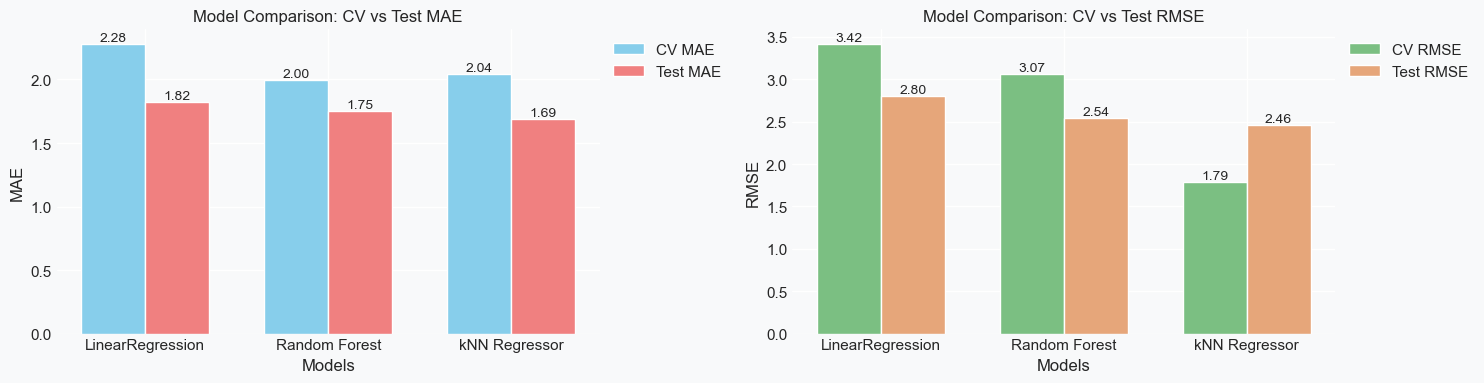

In [198]:
import matplotlib.pyplot as plt
import numpy as np

# Define the metric scores for MAE and RMSE
# mae for all models
metric_scores_mae = {
    'LinearRegression': [cv_mae_lr, lr_test_mae],
    'Random Forest': [avgtunedrf_cv_mae, bestrf_test_mae],
    'kNN Regressor': [cv_knn_mae, knn_test_mae]
}

# rmse for all models
metric_scores_rmse = {
    'LinearRegression': [cv_rmse_lr, lr_test_rmse],
    'Random Forest': [avgtunedrf_cv_rmse, bestrf_test_rmse],
    'kNN Regressor': [cv_knn_rmse, knn_test_rmse]
}

# Extract model names, CV and Test values for both MAE and RMSE
models = list(metric_scores_mae.keys())
cv_mae = [scores[0] for scores in metric_scores_mae.values()]
test_mae = [scores[1] for scores in metric_scores_mae.values()]

cv_rmse = [scores[0] for scores in metric_scores_rmse.values()]
test_rmse = [scores[1] for scores in metric_scores_rmse.values()]

# Bar width
bar_width = 0.35
index = np.arange(len(models))

# Set up the figure
plt.figure(figsize=(15, 4))

# First subplot for MAE
plt.subplot(1, 2, 1)
bar1 = plt.bar(index, cv_mae, bar_width, label='CV MAE', color='skyblue')
bar2 = plt.bar(index + bar_width, test_mae, bar_width, label='Test MAE', color='lightcoral')

# Add values on top of each MAE bar
for rect in bar1:
    plt.text(rect.get_x() + rect.get_width() / 2, rect.get_height(), f'{rect.get_height():.2f}',
             ha='center', va='bottom', fontsize=10)
for rect in bar2:
    plt.text(rect.get_x() + rect.get_width() / 2, rect.get_height(), f'{rect.get_height():.2f}',
             ha='center', va='bottom', fontsize=10)

# Labeling the MAE plot
plt.xlabel('Models')
plt.ylabel('MAE')
plt.title('Model Comparison: CV vs Test MAE')
plt.xticks(index + bar_width / 2, models)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Second subplot for RMSE
plt.subplot(1, 2, 2)
bar3 = plt.bar(index, cv_rmse, bar_width, label='CV RMSE', color='#7bbf82')
bar4 = plt.bar(index + bar_width, test_rmse, bar_width, label='Test RMSE', color='#e6a67a')

# Add values on top of each RMSE bar
for rect in bar3:
    plt.text(rect.get_x() + rect.get_width() / 2, rect.get_height(), f'{rect.get_height():.2f}',
             ha='center', va='bottom', fontsize=10)
for rect in bar4:
    plt.text(rect.get_x() + rect.get_width() / 2, rect.get_height(), f'{rect.get_height():.2f}',
             ha='center', va='bottom', fontsize=10)

# Labeling the RMSE plot
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.title('Model Comparison: CV vs Test RMSE')
plt.xticks(index + bar_width / 2, models)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Adjust layout
plt.tight_layout()
plt.show()


It appears that all 3 models performed better on the **test (unseen) data**, excluding the **KNN Regressor**, as the **RMSE** indicates a slight **overfitting**, though not significant, compared to their performance during **cross-validation (training data)**, which is somewhat unusual. However, this could be attributed to the relatively small size of our **dataset**. With only **389 rows of data**, the test set likely contains fewer data points, and it may be less noisy, more representative, or exhibit simpler patterns than the training data. If the test set contains fewer **outliers** or **edge cases**, the models may find it easier to make accurate predictions. In some cases, it could also be due to **data leakage**, but in this case, the data was carefully preprocessed to prevent this.


- **Test Set Easiness Bias**  
  - Random sampling may result in a test set that's simpler, less noisy, or more homogeneous.  
  - If the test set lacks difficult edge cases or outliers, models may appear to perform better than they actually generalize.

- **Cross-Validation as a Mitigation Strategy**  
  - A single train-test split can give unreliable results, especially with small datasets.  
  - Cross-validation averages performance across multiple splits, reducing variance and the impact of an "accidentally easy" test set.  
  - However, cross-validation didn’t fully eliminate the discrepancy, possibly due to the limited size and variability of the dataset.


**Which model Performs the best?**

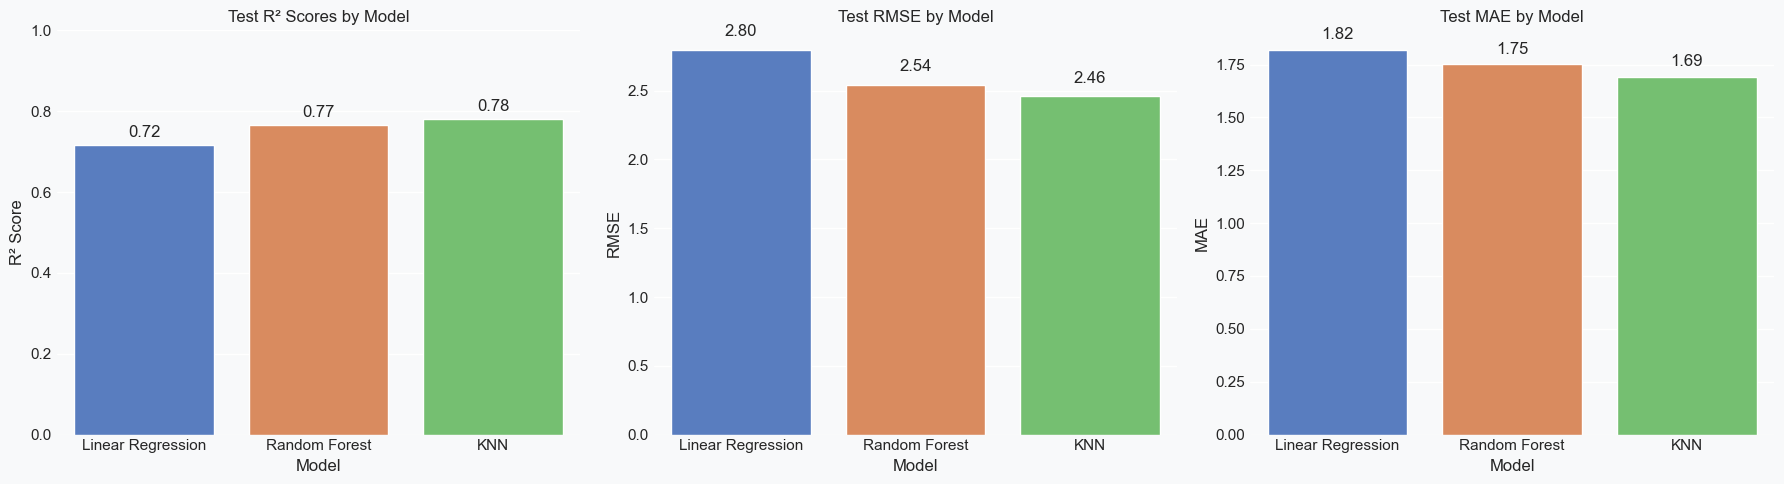

In [194]:
# create list of model names used
models = ['Linear Regression', 'Random Forest', 'KNN']

# Create DataFrames to store metrics
r2_df = pd.DataFrame({'Model': models, 'R² Score': [lr_test_r2, bestrf_test_r2, knn_test_r2]})
rmse_df = pd.DataFrame({'Model': models, 'RMSE': [lr_test_rmse, bestrf_test_rmse, knn_test_rmse]})
mae_df = pd.DataFrame({'Model': models, 'MAE': [lr_test_mae, bestrf_test_mae, knn_test_mae]})

# Plot all three metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² Plot
sns.barplot(ax=axes[0], x='Model', y='R² Score', data=r2_df, palette='muted')
axes[0].set_ylim(0, 1)
axes[0].set_title('Test R² Scores by Model')
for i, v in enumerate(r2_df['R² Score']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center')

# RMSE Plot
sns.barplot(ax=axes[1], x='Model', y='RMSE', data=rmse_df, palette='muted')
axes[1].set_title('Test RMSE by Model')
for i, v in enumerate(rmse_df['RMSE']):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center')

# MAE Plot
sns.barplot(ax=axes[2], x='Model', y='MAE', data=mae_df, palette='muted')
axes[2].set_title('Test MAE by Model')
for i, v in enumerate(mae_df['MAE']):
    axes[2].text(i, v + 0.05, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()


- All models demonstrated strong performance, with prediction errors remaining within a margin of less than 3 MPG from the true values.

- While the RMSE values are slightly higher than the corresponding MAE values,reflecting their sensitivity to larger errors, the MAE scores consistently indicate that, on average, the predicted MPG values deviate from the actual values by  2.4 to 3 MPG. 
- **KNN** achieved the highest R² Score (**0.78**), indicating it explained the most variance in the target variable.

- It also recorded the lowest RMSE (**2.46**) and MAE (**1.69**), reflecting better predictive accuracy and lower average error compared to the other models.

Based on this comprehensive evaluation, **K-Nearest Neighbors (KNN)** is selected as the final model, as it consistently outperformed the alternatives across all metrics.

---

## **Conclusion and Future Work**
<a id="nine"></a>
<a href=#cont>Back to Table of Contents</a>



#### **Key Insights**

- **Engine Size and Efficiency:**  
  Cars with smaller engines—typically those with fewer cylinders and lower engine displacement—tend to be more fuel efficient. Larger engines, while offering more power, generally consume more fuel.

- **Hybrid Vehicles:**  
  Hybrid cars demonstrate excellent fuel economy, thanks to their ability to switch between electric and fuel-powered modes, especially in stop-and-go traffic.

- **Drivetrain Influence:**  
  Front-wheel drive (FWD) vehicles often deliver better fuel efficiency compared to rear-wheel drive (RWD) or all-wheel drive (AWD) systems, due to reduced drivetrain losses and lighter overall weight.

- **Vehicle Class Matters:**  
  Compact cars are generally more fuel-efficient than larger vehicles like SUVs or trucks. Their lighter weight and smaller engines contribute to lower fuel consumption.

- **Impact of Cylinders and Displacement:**  
  Both the number of cylinders and engine displacement are key factors affecting fuel consumption. More cylinders and higher displacement usually mean more fuel burned per kilometer driven.

- **Driving Conditions:**  
  Fuel efficiency tends to be better during highway driving compared to city driving. Constant speeds and fewer stops on highways contribute to lower fuel usage, whereas frequent acceleration and braking in city traffic increase consumption.

- **Long-Term Trends:**  
  Over the past decade, fuel economy figures have shown some fluctuations due to varying vehicle technologies, market demands, and regulations. However, the overall trend is positive, with gradual improvements in average MPG (miles per gallon) driven by advancements in engine design, hybrid technology, and fuel efficiency standards.
You can copy and paste this markdown directly into your document or platform. Let me know if you'd like further adjustments!

- **Model Development:**
  - Three models, Linear Regression, Random Forest, and K-Nearest Neighbors (KNN) were trained to predict fuel efficiency. After evaluating the models using key metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R², the results revealed that the KNN model outperformed the others in terms of accuracy and predictive power.

  - The KNN model achieved the best performance, with the lowest MAE and RMSE values, as well as the highest R² score on the test set, indicating that it was able to capture the underlying patterns in the data more effectively than both Linear Regression and Random Forest. Specifically, the final MAE for KNN was 1.59, and the R² on the test set was 0.83, showing a strong fit to the data.

  - In contrast, while the Linear Regression and Random Forest models showed reasonable performance, they did not achieve the same level of accuracy, with higher errors and lower R² values. This highlights the potential of KNN in dealing with non-linear relationships and complex interactions between features in the dataset.









##### **Recomendations**

- Manufacturers should prioritize hybrid vehicles for better fuel efficiency and lower emissions.
- Focus on cars with fewer cylinders and smaller engines, using technologies like turbocharging for speed without compromising efficiency.
- Consumers should utilize fuel economy models to find the most fuel-efficient cars.
- Regular maintenance is key to sustaining fuel efficiency and vehicle performance.

**model improvement**

- Collecting more data will provide a wider and more balanced dataset, helping the model generalize better and capture more diverse patterns.
- Including vehicle weight as a feature will improve the model’s predictive power and explained variance, as weight is a key factor in fuel consumption.
- Further Fine-tune model parameters for better performance.


---

## **References**
<a id="ten"></a>
<a href=#cont>Back to Table of Contents</a>



Arslaan Siddiqui. (2024). car_data [Data set]. Kaggle. https://www.kaggle.com/datasets/arslaan5/explore-car-performance-fuel-efficiency-data/data
Licensed under GNU General Public License v3.0.